# LAB013–LAB015: information added by reliable offline measurements

This notebook compares a historical natural-must calibration with an augmented
global calibration that adds reliable offline observations from the nominal
triplicate LAB013–LAB015. The gas-phase CO$_2$ measurements from these three
reactors have known measurement problems and are **never used for parameter
estimation**. They are loaded only in a separated diagnostic block.

The biological parameters remain shared across all experiments. No data file,
model source file, or other notebook is written by this analysis.

## Methodological change and scenarios

- **A — historical baseline:** the saved natural-must fit from
  `estimability_historical_natural`, based on nine historical natural-must
  batches and the repository's existing scaled multistate residuals.
- **B — augmented global fit:** the identical historical residual block plus
  scientifically compatible offline LAB013–LAB015 observations.
- The natural-must gas-transfer parameters remain fixed at their prior fit.
  They are not re-estimated here.
- LAB013–LAB015 gas CO$_2$ is absent from both objective functions. No
  apparently “good” subinterval is selected.

Historical gas-phase CO$_2$ is also absent from the biological calibration
objective in the existing repository workflow (`co2_values_used_in_parameter_fit`
is false). Its trusted calibration/holdout curves are evaluated after fitting as
an independent preservation check using the existing fixed CO$_2$ observation
layer.

In [1]:
from pathlib import Path
import json
import math
import sys
import warnings
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.optimize import least_squares

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "fermentation_model").is_dir():
            return candidate
    raise RuntimeError("Repository root containing fermentation_model was not found")

ROOT = find_repo_root(Path.cwd())
FM = ROOT / "fermentation_model"
for module_path in (FM, FM / "laboratory_2026", FM / "pilot_2025"):
    if str(module_path) not in sys.path:
        sys.path.insert(0, str(module_path))

from shared import new_must_data_loader
from shared import run_new_must_glycerol_estimability_doe as base
from laboratory_2026 import run_estimability_historical_by_medium as historical
from laboratory_2026 import run_final_operational_doe_v2 as final
from laboratory_2026 import run_co2_matrix_cross_validation_2026 as co2_layer

DATA_DIR = FM / "data" / "mem2026" / "LAB013-015"
HIST_RESULTS = FM / "laboratory_2026" / "results" / "estimability_historical_natural"
CO2_RESULTS = FM / "laboratory_2026" / "results" / "co2_matrix_cross_validation_2026"
LABS = ("LAB013", "LAB014", "LAB015")
LAB_TO_F = {"LAB013": "F1", "LAB014": "F2", "LAB015": "F3"}
REACTOR_VOLUME_L = 2.0

print("Repository root:", ROOT.name)
print("Biological state vector:", base.STATE_NAMES)
print("Shared fitted parameters:", final.FERMENTATION_TARGETS)

Repository root: pyomo-doe
Biological state vector: ('X', 'Xd', 'N', 'G', 'F', 'E', 'Gly')
Shared fitted parameters: ('mu0', 'qN', 'betaG0', 'betaF0', 'qEG', 'qEF', 'iG', 'iE', 'Kd0', 'gammaG0', 'gammaF0')


## 1. Source and schema audit

All paths below are repository-relative. The requested cleaned Y15 filename is
checked explicitly. If it is absent, the available processed CSV is used without
modifying or renaming it. `LABxxx-PI` rows are pre-inoculum measurements: they
provide must composition for initial conditions but are not dynamic sample 1 and
contribute no residual.

In [2]:
requested = {
    "offline": DATA_DIR / "LAB013-LAB015-offline-measurements.csv",
    "combined": DATA_DIR / "LAB013-LAB015-offline-combined.csv",
    "y15_clean_requested": DATA_DIR / "Y15_LAB013-015_clean.csv",
    "y15_available_fallback": DATA_DIR / "Y15_LAB013-015.csv",
    "dissolved_reference": FM / "data" / "mem2026" / "Tabla_CO2_disuelto_carbodoseur_long.csv",
    "historical_theta": HIST_RESULTS / "theta.csv",
    "historical_summary": HIST_RESULTS / "summary.json",
    "co2_layer_parameters": CO2_RESULTS / "fit_parameters.csv",
    "historical_co2": CO2_RESULTS / "co2_observations_hourly.csv",
}
source_audit = pd.DataFrame(
    [{"source": key, "relative_path": path.relative_to(ROOT).as_posix(), "exists": path.exists()}
     for key, path in requested.items()]
)
display(source_audit)
for required_key in ("offline", "combined", "y15_available_fallback", "historical_theta",
                     "historical_summary", "co2_layer_parameters", "historical_co2"):
    assert requested[required_key].exists(), requested[required_key]

Y15_PATH = (requested["y15_clean_requested"] if requested["y15_clean_requested"].exists()
            else requested["y15_available_fallback"])
if not requested["y15_clean_requested"].exists():
    print("AUDIT NOTE: Y15_LAB013-015_clean.csv is absent; using existing processed Y15_LAB013-015.csv.")

,source,relative_path,exists
0,offline,fermentation_model/data/mem2026/LAB013-015/LAB...,True
1,combined,fermentation_model/data/mem2026/LAB013-015/LAB...,True
2,y15_clean_requested,fermentation_model/data/mem2026/LAB013-015/Y15...,False
3,y15_available_fallback,fermentation_model/data/mem2026/LAB013-015/Y15...,True
4,dissolved_reference,fermentation_model/data/mem2026/Tabla_CO2_disu...,True
5,historical_theta,fermentation_model/laboratory_2026/results/est...,True
6,historical_summary,fermentation_model/laboratory_2026/results/est...,True
7,co2_layer_parameters,fermentation_model/laboratory_2026/results/co2...,True
8,historical_co2,fermentation_model/laboratory_2026/results/co2...,True


AUDIT NOTE: Y15_LAB013-015_clean.csv is absent; using existing processed Y15_LAB013-015.csv.


## 2. State–observable compatibility

The current biological implementation has separate glucose (`G`) and fructose
(`F`) states rather than a single `S`. The Y15 total is therefore observed with
the exact algebraic observation function

$$H_S(x)=G+F.$$

This avoids fitting the same Y15 assay twice through its reported components.
The repository loader explicitly defines `N_kg_m3 = YAN_mg_l × 10⁻³`, so YAN is
compatible with `N`; ammonia and PAN remain component-level validation. Glycerol
maps directly to `Gly`.

The gas-transfer layer already contains a latent dissolved-CO$_2$ pool. It is
exposed below by replaying the exact existing mass-balance update from
`raw_qgas_grid_prediction`; no state or equation is added. Measured mg/L is
converted to g/L. The initial dissolved measurement is validation-only because
the existing layer fixes the latent pool to zero at model time zero.

In [3]:
mapping = pd.DataFrame([
    {"measurement": "glucose_fructose_g_L", "model observable": "G + F", "unit conversion": "none (g/L)", "role": "fit"},
    {"measurement": "YAN_mg_L", "model observable": "N", "unit conversion": "× 1e-3 → kg/m³", "role": "fit"},
    {"measurement": "glycerol_g_L", "model observable": "Gly", "unit conversion": "none (g/L)", "role": "fit"},
    {"measurement": "CO2_dissolved_actualT_mg_L (t>0)", "model observable": "existing latent dissolved CO2 pool", "unit conversion": "× 1e-3 → g/L", "role": "fit"},
    {"measurement": "CO2_dissolved_actualT_mg_L (t=0)", "model observable": "latent pool fixed to zero initially", "unit conversion": "× 1e-3 → g/L", "role": "validation"},
    {"measurement": "ammonia_mg_L, PAN_mg_L", "model observable": "no component states", "unit conversion": "none", "role": "validation"},
    {"measurement": "Brix, density", "model observable": "no repository observation function used here", "unit conversion": "none", "role": "validation"},
    {"measurement": "dissolved O2", "model observable": "not a biological-fit state", "unit conversion": "none", "role": "validation"},
    {"measurement": "LAB013–LAB015 gas CO2", "model observable": "gas observation layer", "unit conversion": "sccm → g/L/h for display", "role": "diagnostic only; excluded"},
])
display(mapping)
assert new_must_data_loader.MG_L_TO_KG_M3 == 1e-3
assert base.STATE_COLUMNS["N"] == "N_kg_m3"
assert base.STATE_COLUMNS["Gly"] == "glycerol_g_l"

,measurement,model observable,unit conversion,role
0,glucose_fructose_g_L,G + F,none (g/L),fit
1,YAN_mg_L,N,× 1e-3 → kg/m³,fit
2,glycerol_g_L,Gly,none (g/L),fit
3,CO2_dissolved_actualT_mg_L (t>0),existing latent dissolved CO2 pool,× 1e-3 → g/L,fit
4,CO2_dissolved_actualT_mg_L (t=0),latent pool fixed to zero initially,× 1e-3 → g/L,validation
5,"ammonia_mg_L, PAN_mg_L",no component states,none,validation
6,"Brix, density",no repository observation function used here,none,validation
7,dissolved O2,not a biological-fit state,none,validation
8,LAB013–LAB015 gas CO2,gas observation layer,sccm → g/L/h for display,diagnostic only; excluded


## 3. Historical baseline

The same loader, equations, parameter bounds, state error floors, and relative
errors used by the prior natural-must analysis are reused. Scenario A is loaded
from the saved result rather than refitted or silently redefined.

In [4]:
historical_data, historical_batches, historical_co2_times, historical_tables = historical.make_medium_batches("natural")
theta_table = pd.read_csv(requested["historical_theta"])
theta_A = dict(base.DEFAULT_THETA)
theta_A.update(dict(zip(theta_table["parameter"], theta_table["theta"])))
theta_A = {name: float(value) for name, value in theta_A.items()}
CORE_PARAMETERS = tuple(final.FERMENTATION_TARGETS)
historical_summary = json.loads(requested["historical_summary"].read_text(encoding="utf-8"))

assert historical_summary["co2_values_used_in_parameter_fit"] is False
historical_batch_audit = pd.DataFrame([
    {
        "batch": batch.batch,
        "n_model_times": len(batch.time),
        "n_scaled_state_observations": sum(np.isfinite(batch.observations[s]).sum() for s in base.STATE_NAMES),
        "t_end_h": float(batch.time.max()),
    }
    for batch in historical_batches
])
display(historical_batch_audit)
print("Historical natural batches:", len(historical_batches))
print("Historical gas CO2 values used in the prior biological fit:", historical_summary["co2_values_used_in_parameter_fit"])

,batch,n_model_times,n_scaled_state_observations,t_end_h
0,LAB004,89,81,163.0
1,LAB005,89,81,163.0
2,LAB006,114,93,211.0
3,LAB007,82,84,160.0
4,LAB008,82,84,160.0
5,LAB009,82,77,160.0
6,LAB010,101,38,187.0
7,LAB011,87,34,163.0
8,LAB012,88,36,163.0


Historical natural batches: 9
Historical gas CO2 values used in the prior biological fit: False


## 4. LAB013–LAB015 synchronization and offline audit

Model time zero remains the first numbered chemical sample, consistent with the
historical workflow. Y15 timestamps are retained at their actual analysis times.
The PI records remain distinct and are never relabeled as sample 1.

In [5]:
offline = pd.read_csv(requested["offline"])
combined_source = pd.read_csv(requested["combined"])
y15 = pd.read_csv(Y15_PATH)

offline["sample_datetime"] = pd.to_datetime(
    offline["fecha_muestreo"].astype(str) + " " + offline["hora_muestreo"].astype(str), errors="coerce"
)
y15["y15_datetime"] = pd.to_datetime(y15["y15_datetime"], errors="coerce")
t0_by_lab = (
    offline[offline["sample_id"].str.endswith("-1")]
    .set_index("lab_id")["sample_datetime"].to_dict()
)
offline["time_h_model"] = [
    (stamp - t0_by_lab[lab]).total_seconds() / 3600.0
    for lab, stamp in zip(offline["lab_id"], offline["sample_datetime"])
]
y15["time_h_model"] = [
    np.nan if str(sample_type) == "pre_inoculum" else (stamp - t0_by_lab[lab]).total_seconds() / 3600.0
    for lab, stamp, sample_type in zip(y15["lab_id"], y15["y15_datetime"], y15["sample_type"])
]

numeric_offline = ["time_h_model", "brix_degBx", "rho_value", "temperature_C", "DO_value", "CO2_dissolved_actualT_mg_L"]
numeric_y15 = ["time_h_model", "YAN_mg_L", "ammonia_mg_L", "PAN_mg_L", "glucose_g_L",
               "glucose_fructose_g_L", "fructose_g_L", "glycerol_g_L"]
for column in numeric_offline:
    offline[column] = pd.to_numeric(offline[column], errors="coerce")
for column in numeric_y15:
    y15[column] = pd.to_numeric(y15[column], errors="coerce")

pi = y15[y15["sample_type"].eq("pre_inoculum")].copy()
dynamic_y15 = y15[y15["sample_type"].eq("fermentation_sample")].dropna(subset=["time_h_model"]).copy()
assert set(pi["sample_id"]) == {f"{lab}-PI" for lab in LABS}
assert not dynamic_y15["sample_id"].str.endswith("-PI").any()

coverage_rows = []
for lab in LABS:
    off = offline[offline["lab_id"].eq(lab)]
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)]
    coverage_rows.append({
        "lab_id": lab,
        "numbered_offline_samples": len(off),
        "dynamic_Y15_samples": len(dyn),
        "pre_inoculum_rows": int(pi["lab_id"].eq(lab).sum()),
        "S_points": int(dyn["glucose_fructose_g_L"].notna().sum()),
        "N_points": int(dyn["YAN_mg_L"].notna().sum()),
        "Gly_points": int(dyn["glycerol_g_L"].notna().sum()),
        "dissolved_CO2_fit_points_t_gt_0": int((off["CO2_dissolved_actualT_mg_L"].notna() & off["time_h_model"].gt(0)).sum()),
        "DO_missing": int(off["DO_value"].isna().sum()),
        "t_end_h": float(off["time_h_model"].max()),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage)
display(pi[["sample_id", "sample_type", "YAN_mg_L", "glucose_g_L", "fructose_g_L", "glycerol_g_L"]])
print("Combined source rows/columns:", combined_source.shape)

,lab_id,numbered_offline_samples,dynamic_Y15_samples,pre_inoculum_rows,S_points,N_points,Gly_points,dissolved_CO2_fit_points_t_gt_0,DO_missing,t_end_h
0,LAB013,10,7,1,7,7,7,6,2,143.5
1,LAB014,10,7,1,7,7,7,6,2,143.5
2,LAB015,10,7,1,7,7,7,6,2,143.5


,sample_id,sample_type,YAN_mg_L,glucose_g_L,fructose_g_L,glycerol_g_L
0,LAB013-PI,pre_inoculum,249.0,75.62,79.03,1.15
8,LAB014-PI,pre_inoculum,247.0,76.54,80.38,1.12
16,LAB015-PI,pre_inoculum,246.0,75.32,79.45,1.12


Combined source rows/columns: (30, 27)


## 5. Replicate trajectories and validation measurements

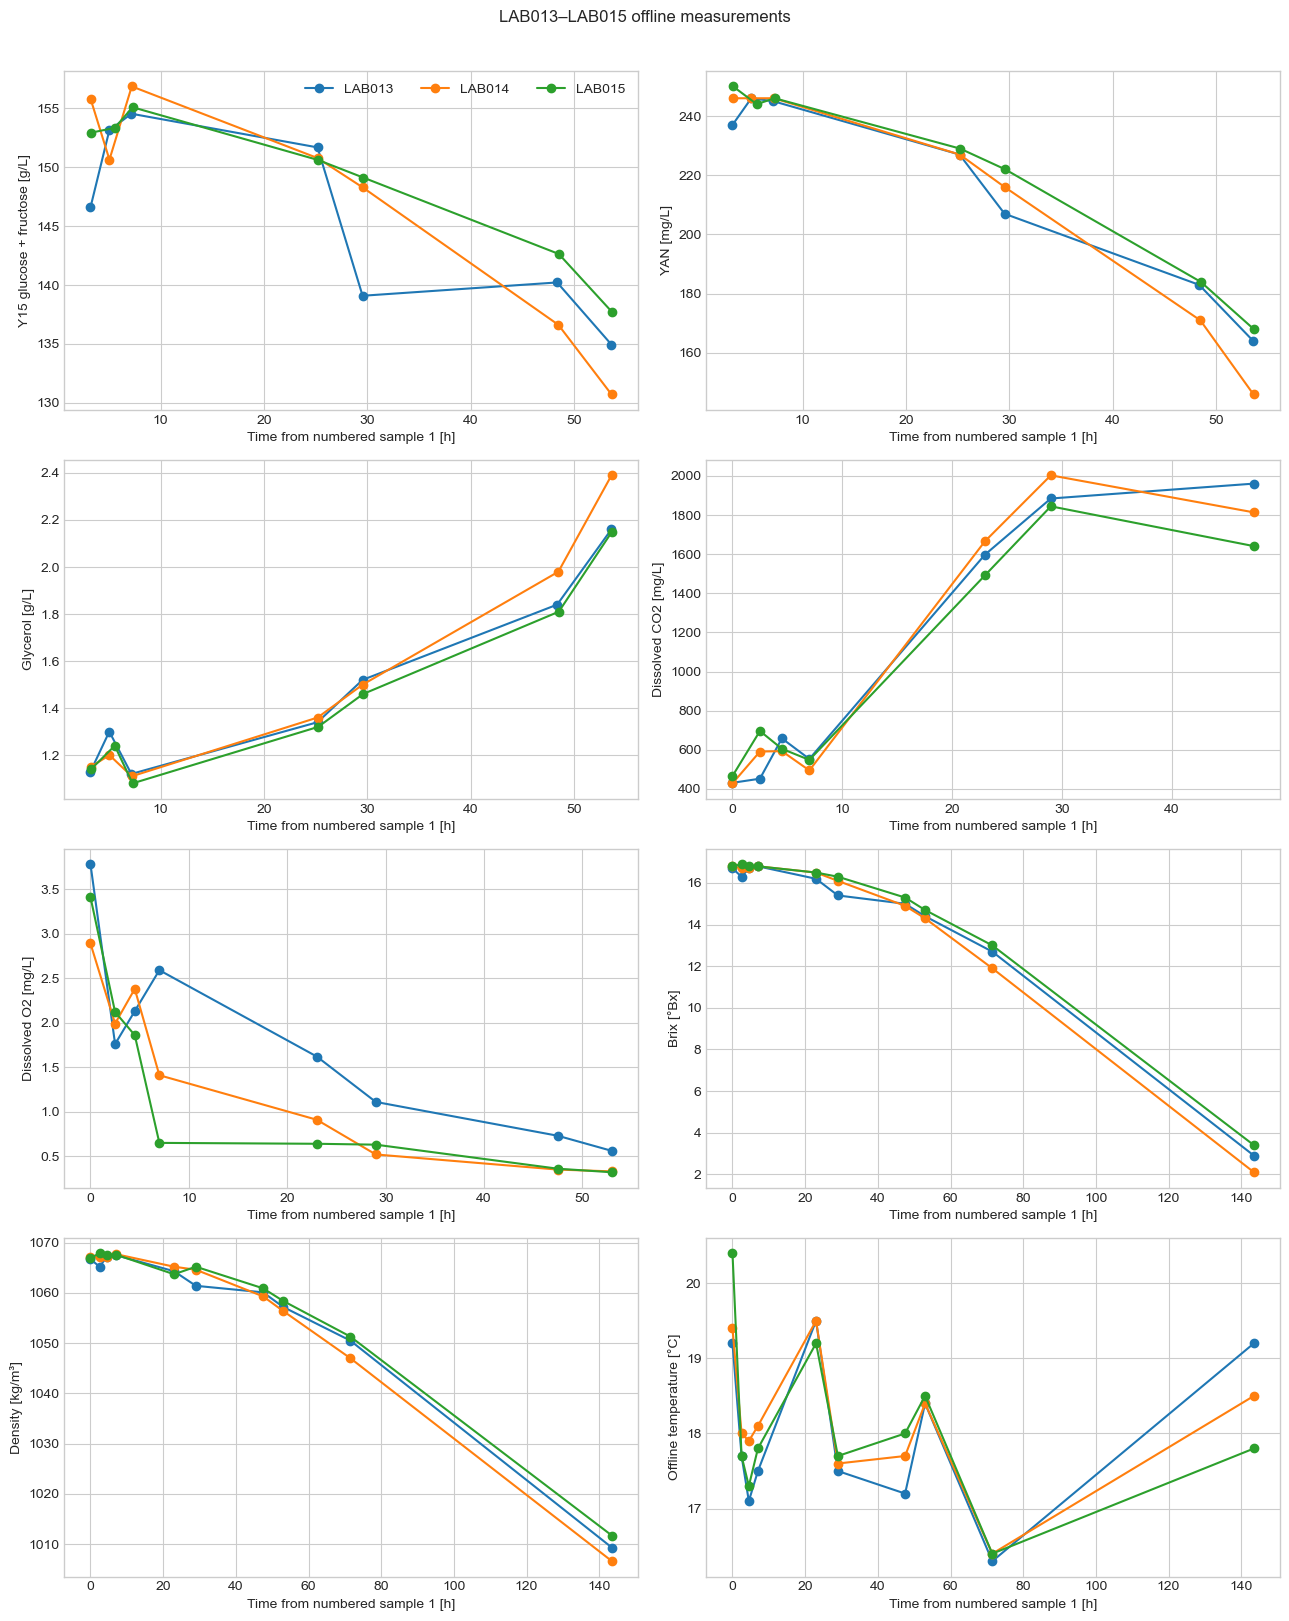

,lab_id,mean_YAN_mg_L,mean_ammonia_plus_PAN_mg_L,mean_component_minus_YAN_mg_L,correlation
0,LAB013,215.571429,243.000000,27.428571,0.999874
1,LAB014,214.000000,241.142857,27.142857,0.999901
2,LAB015,220.428571,248.857143,28.428571,0.999925


In [6]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16), sharex=False)
panels = [
    ("glucose_fructose_g_L", "Y15 glucose + fructose [g/L]", dynamic_y15, "time_h_model"),
    ("YAN_mg_L", "YAN [mg/L]", dynamic_y15, "time_h_model"),
    ("glycerol_g_L", "Glycerol [g/L]", dynamic_y15, "time_h_model"),
    ("CO2_dissolved_actualT_mg_L", "Dissolved CO2 [mg/L]", offline, "time_h_model"),
    ("DO_value", "Dissolved O2 [mg/L]", offline, "time_h_model"),
    ("brix_degBx", "Brix [°Bx]", offline, "time_h_model"),
    ("rho_value", "Density [kg/m³]", offline, "time_h_model"),
    ("temperature_C", "Offline temperature [°C]", offline, "time_h_model"),
]
for ax, (column, ylabel, frame, time_column) in zip(axes.ravel(), panels):
    for lab in LABS:
        group = frame[frame["lab_id"].eq(lab)].dropna(subset=[time_column, column])
        ax.plot(group[time_column], group[column], marker="o", label=lab)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time from numbered sample 1 [h]")
axes[0, 0].legend(ncol=3)
fig.suptitle("LAB013–LAB015 offline measurements", y=1.01)
fig.tight_layout()
plt.show()

nitrogen_check = dynamic_y15.assign(
    ammonia_plus_PAN_mg_L=dynamic_y15["ammonia_mg_L"] + dynamic_y15["PAN_mg_L"]
)
nitrogen_component_audit = nitrogen_check.groupby("lab_id").apply(
    lambda g: pd.Series({
        "mean_YAN_mg_L": g["YAN_mg_L"].mean(),
        "mean_ammonia_plus_PAN_mg_L": g["ammonia_plus_PAN_mg_L"].mean(),
        "mean_component_minus_YAN_mg_L": (g["ammonia_plus_PAN_mg_L"] - g["YAN_mg_L"]).mean(),
        "correlation": g[["YAN_mg_L", "ammonia_plus_PAN_mg_L"]].corr().iloc[0, 1],
    }), include_groups=False
).reset_index()
display(nitrogen_component_audit)

## 6. Gas-phase CO$_2$: separated diagnostic data

These signals are loaded into `gas_reference` only. That object is not accepted
by the biological residual function defined later. All panels carry the explicit
exclusion notice. Gas-linked lag estimates from the previous version are not
retained because a delay inferred from known faulty signals would not be a
defensible kinetic result.

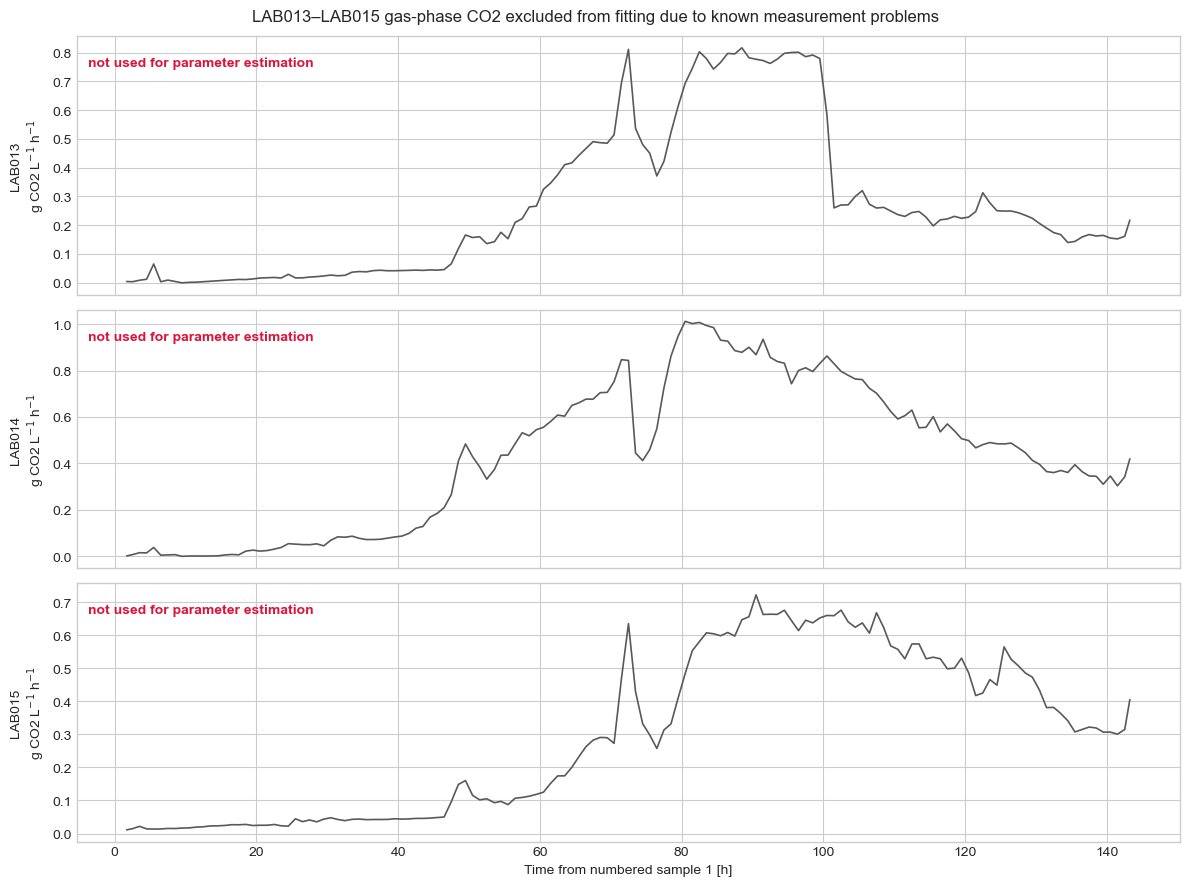

,n_hourly,used_in_fit
lab_id,,
LAB013,143,False
LAB014,143,False
LAB015,143,False


In [7]:
gas_frames = []
for lab, fermenter in LAB_TO_F.items():
    path = DATA_DIR / f"CO2_FILT_{fermenter}_{lab}.csv"
    frame = pd.read_csv(path)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], errors="coerce")
    frame["flow_filt_sccm"] = pd.to_numeric(frame["flow_filt_sccm"], errors="coerce")
    frame["lab_id"] = lab
    frame["t_h"] = (frame["timestamp"] - t0_by_lab[lab]).dt.total_seconds() / 3600.0
    frame = frame[frame["t_h"].between(0.0, float(offline.loc[offline["lab_id"].eq(lab), "time_h_model"].max()))]
    frame["hour"] = np.floor(frame["t_h"]).astype(int)
    hourly = frame.groupby(["lab_id", "hour"], as_index=False).agg(
        t_h=("t_h", "median"), flow_sccm=("flow_filt_sccm", "median"), spike_fraction=("is_spike", "mean")
    )
    hourly["co2_rate_g_l_h"] = (
        hourly["flow_sccm"] * 60.0 / 1000.0 * co2_layer.CO2_MOLAR_MASS_G_MOL
        / co2_layer.STANDARD_MOLAR_VOLUME_L_MOL / REACTOR_VOLUME_L
    )
    hourly["used_in_fit"] = False
    gas_frames.append(hourly)
gas_reference = pd.concat(gas_frames, ignore_index=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, lab in zip(axes, LABS):
    group = gas_reference[gas_reference["lab_id"].eq(lab)]
    ax.plot(group["t_h"], group["co2_rate_g_l_h"], color="0.35", lw=1.2)
    ax.set_ylabel(f"{lab}\ng CO2 L$^{{-1}}$ h$^{{-1}}$")
    ax.text(0.01, 0.92, "not used for parameter estimation", transform=ax.transAxes,
            color="crimson", weight="bold", va="top")
axes[-1].set_xlabel("Time from numbered sample 1 [h]")
fig.suptitle("LAB013–LAB015 gas-phase CO2 excluded from fitting due to known measurement problems")
fig.tight_layout()
plt.show()
display(gas_reference.groupby("lab_id").agg(n_hourly=("t_h", "size"), used_in_fit=("used_in_fit", "any")))

## 7. LAB013–LAB015 model batches and initial conditions

Reactor-specific initial must composition comes from each PI row. Biomass,
dead biomass, and ethanol were not measured and use the existing natural-must
fallbacks (`X=0.45 kg/m³`, `Xd=0`, `E=0`). No nutrient pulse is present in the
temperature acquisition files. Temperatures are resampled to 30-minute medians;
the numbered sample-1 temperature anchors the interval before sensor acquisition.

In [8]:
lab_batches = {}
temperature_inputs = []
for lab, fermenter in LAB_TO_F.items():
    off = offline[offline["lab_id"].eq(lab)].sort_values("time_h_model")
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    pi_row = pi[pi["lab_id"].eq(lab)].iloc[0]
    temp = pd.read_csv(DATA_DIR / f"Temp_{fermenter}_{lab}.csv", usecols=["timestamp", "T", "nutricion_activa"])
    temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
    temp["T"] = pd.to_numeric(temp["T"], errors="coerce")
    assert pd.to_numeric(temp["nutricion_activa"], errors="coerce").fillna(0).eq(0).all()
    temp = temp.dropna(subset=["timestamp", "T"]).set_index("timestamp")["T"].resample("30min").median().dropna().reset_index()
    temp["time_h_model"] = (temp["timestamp"] - t0_by_lab[lab]).dt.total_seconds() / 3600.0
    horizon = float(off["time_h_model"].max())
    temp = temp[temp["time_h_model"].between(0.0, horizon)]
    anchor = pd.DataFrame({"timestamp": [t0_by_lab[lab]], "T": [float(off.iloc[0]["temperature_C"])], "time_h_model": [0.0]})
    temp = pd.concat([anchor, temp], ignore_index=True).sort_values("time_h_model").drop_duplicates("time_h_model")
    temperature_inputs.append(temp.assign(lab_id=lab))

    model_time = np.unique(np.concatenate([
        np.array([0.0, horizon]), off["time_h_model"].dropna().to_numpy(float),
        dyn["time_h_model"].dropna().to_numpy(float), temp["time_h_model"].to_numpy(float)
    ]))
    temperature = np.interp(model_time, temp["time_h_model"], temp["T"])
    observations = {state: np.full(len(model_time), np.nan) for state in base.STATE_NAMES}
    for _, row in dyn.iterrows():
        idx = int(np.argmin(np.abs(model_time - float(row["time_h_model"]))))
        observations["N"][idx] = float(row["YAN_mg_L"]) * 1e-3
        observations["G"][idx] = float(row["glucose_g_L"])
        observations["F"][idx] = float(row["fructose_g_L"])
        observations["Gly"][idx] = float(row["glycerol_g_L"])
    initials = {
        "X": 0.45, "Xd": 0.0,
        "N": float(pi_row["YAN_mg_L"]) * 1e-3,
        "G": float(pi_row["glucose_g_L"]), "F": float(pi_row["fructose_g_L"]),
        "E": 0.0, "Gly": float(pi_row["glycerol_g_L"]),
    }
    lab_batches[lab] = base.BatchData(
        medium="natural", batch=lab, time=model_time, temperature_c=temperature,
        pulses={channel: tuple() for channel in base.INPUT_CHANNELS},
        observations=observations, initials=initials,
    )

temperature_inputs = pd.concat(temperature_inputs, ignore_index=True)
initial_conditions = pd.DataFrame([{"lab_id": lab, **batch.initials} for lab, batch in lab_batches.items()])
display(initial_conditions)
display(temperature_inputs.groupby("lab_id")["T"].agg(["count", "min", "mean", "max"]))

,lab_id,X,Xd,N,G,F,E,Gly
0,LAB013,0.45,0.0,0.249,75.62,79.03,0.0,1.15
1,LAB014,0.45,0.0,0.247,76.54,80.38,0.0,1.12
2,LAB015,0.45,0.0,0.246,75.32,79.45,0.0,1.12


,count,min,mean,max
lab_id,,,,
LAB013,287,15.6,16.012544,19.2
LAB014,287,15.6,16.033624,19.4
LAB015,287,15.6,16.015157,20.4


## 8. Fixed CO$_2$ observation layer and dissolved-pool wrapper

The wrapper below calls the repository's `raw_qgas_grid_prediction` and reconstructs
its latent dissolved pool from the same discrete balance

$$C_{k}=\max\{C_{k-1}+\Delta t(q_{prod,k-1}-q_{gas,k}),0\}.$$

Only the shared biological parameter vector changes between scenarios. Natural-must
release, saturation, oxygen-gating, activation, and matrix-gain parameters stay at
their trusted historical values. Matrix gain scales the sensor signal and therefore
is not applied to the physical dissolved pool.

In [9]:
co2_parameter_table = pd.read_csv(requested["co2_layer_parameters"])
fixed_co2_parameters = dict(zip(
    co2_parameter_table.loc[co2_parameter_table["calibration_matrix"].eq("natural"), "parameter"],
    co2_parameter_table.loc[co2_parameter_table["calibration_matrix"].eq("natural"), "estimate"],
))
display(co2_parameter_table[co2_parameter_table["calibration_matrix"].eq("natural")])

dissolved_support = pd.concat([
    offline[(offline["lab_id"].eq(lab)) & offline["CO2_dissolved_actualT_mg_L"].notna()]
    .assign(batch=lab, matrix="natural", calibratable=True,
            t_h=lambda x: x["time_h_model"],
            chemistry_last_h=float(lab_batches[lab].time.max()))
    [["batch", "matrix", "calibratable", "t_h", "chemistry_last_h"]]
    for lab in LABS
], ignore_index=True)

def build_lab_driver_cache(theta):
    cache, _ = co2_layer.build_driver_cache(lab_batches, {"natural": theta}, dissolved_support)
    return cache

def dissolved_pool_grid(cache_item):
    qgas, qprod, o2, phi_ana = co2_layer.raw_qgas_grid_prediction(
        cache_item,
        fixed_co2_parameters["kCO2_release_h"],
        fixed_co2_parameters["CO2sat_scale"],
        fixed_co2_parameters["O2_qmax_mg_gdw_h"],
        fixed_co2_parameters["O2_initial_scale"],
        chemistry_aligned=True,
        nitrogen_boost_transition=True,
        pulse_t_rise_h=fixed_co2_parameters["pulse_t_rise_h"],
        pulse_activity_gain=fixed_co2_parameters["pulse_activity_gain"],
        continuous_release=True,
        bounded_chemical_activation=True,
        chem_activation_start_fraction=fixed_co2_parameters["chem_activation_start_fraction"],
        chem_activation_duration_fraction=fixed_co2_parameters["chem_activation_duration_fraction"],
    )
    dissolved = np.zeros(len(cache_item.time_h), dtype=float)
    for idx in range(1, len(cache_item.time_h)):
        dt = float(cache_item.time_h[idx] - cache_item.time_h[idx - 1])
        dissolved[idx] = max(dissolved[idx - 1] + dt * (qprod[idx - 1] - qgas[idx]), 0.0)
    return dissolved, qgas, qprod, o2, phi_ana

,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
9,natural,kCO2_release_h,0.424588,0.03,25.00,False,3.940150e-01
10,natural,CO2sat_scale,0.351389,0.35,2.50,True,2.014272e-03
11,natural,O2_qmax_mg_gdw_h,0.150000,0.15,6.00,True,6.019297e-17
12,natural,O2_initial_scale,0.195400,0.05,1.50,False,4.007483e-01
13,natural,pulse_t_rise_h,64.658714,1.00,72.00,False,2.514651e-02
14,natural,pulse_activity_gain,0.250000,0.25,4.00,True,8.008566e-17
15,natural,chem_activation_start_fraction,0.735057,0.01,0.95,False,5.632878e-02
16,natural,chem_activation_duration_fraction,1.063910,0.35,2.00,False,3.621386e-01
17,natural,matrix_gain,3.115757,0.10,20.00,False,3.509152e-01


## 9. Multivariable, multi-experiment objective

Historical residuals use the repository's state-specific floor-plus-relative
standardization. LAB nitrogen and glycerol use the same functions. The uncertainty
for `G+F` is the root-sum-square of the existing G and F scales evaluated at half
the total. Dissolved CO$_2$ has no pre-existing error model, so a fixed transparent
scale is declared before fitting: `max(0.10 g/L, 10% of the measurement)`.

These weights are measurement-scale choices, not visual tuning. Every biological
kinetic parameter is shared. The objective registry below is the executable proof
of inclusion: it contains no LAB gas-phase CO$_2$ term.

In [10]:
LAB_FIT_OBSERVABLES = (
    "S_total_as_G_plus_F",
    "N_from_YAN",
    "Gly_from_glycerol",
    "dissolved_CO2_existing_pool_t_gt_0",
)
LAB_VALIDATION_ONLY = (
    "gas_phase_CO2", "ammonia", "PAN", "Brix", "density", "dissolved_O2",
    "dissolved_CO2_at_t0",
)
assert "gas_phase_CO2" not in LAB_FIT_OBSERVABLES

def scaled_residual_blocks(theta, include_lab_offline):
    blocks = {}
    for batch in historical_batches:
        simulation = base.simulate(batch, theta, batch.time)
        if simulation is None:
            raise RuntimeError(f"Historical simulation failed for {batch.batch}")
        for state in base.STATE_NAMES:
            observed = np.asarray(batch.observations[state], dtype=float)
            mask = np.isfinite(observed)
            if mask.any():
                predicted = simulation.loc[batch.time, state].to_numpy(float)[mask]
                sigma = base.sigma_for_state(state, observed[mask])
                blocks.setdefault(("historical", state), []).append((predicted - observed[mask]) / sigma)

    if include_lab_offline:
        cache = build_lab_driver_cache(theta)
        for lab, batch in lab_batches.items():
            simulation = base.simulate(batch, theta, batch.time)
            if simulation is None:
                raise RuntimeError(f"LAB simulation failed for {lab}")
            dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
            t = dyn["time_h_model"].to_numpy(float)

            s_obs = dyn["glucose_fructose_g_L"].to_numpy(float)
            s_pred = np.interp(t, simulation.index, simulation["G"] + simulation["F"])
            sigma_g = base.sigma_for_state("G", s_obs / 2.0)
            sigma_f = base.sigma_for_state("F", s_obs / 2.0)
            blocks.setdefault(("LAB013-015 offline", "S=G+F"), []).append(
                (s_pred - s_obs) / np.sqrt(sigma_g**2 + sigma_f**2)
            )

            n_obs = dyn["YAN_mg_L"].to_numpy(float) * 1e-3
            n_pred = np.interp(t, simulation.index, simulation["N"])
            blocks.setdefault(("LAB013-015 offline", "N=YAN"), []).append(
                (n_pred - n_obs) / base.sigma_for_state("N", n_obs)
            )

            gly_obs = dyn["glycerol_g_L"].to_numpy(float)
            gly_pred = np.interp(t, simulation.index, simulation["Gly"])
            blocks.setdefault(("LAB013-015 offline", "Gly"), []).append(
                (gly_pred - gly_obs) / base.sigma_for_state("Gly", gly_obs)
            )

            off = offline[(offline["lab_id"].eq(lab)) &
                          offline["CO2_dissolved_actualT_mg_L"].notna() &
                          offline["time_h_model"].gt(0)].sort_values("time_h_model")
            d_time = off["time_h_model"].to_numpy(float)
            d_obs = off["CO2_dissolved_actualT_mg_L"].to_numpy(float) * 1e-3
            d_grid, *_ = dissolved_pool_grid(cache[lab])
            d_pred = np.interp(d_time, cache[lab].time_h, d_grid)
            d_sigma = np.maximum(0.10, 0.10 * np.abs(d_obs))
            blocks.setdefault(("LAB013-015 offline", "dissolved_CO2"), []).append(
                (d_pred - d_obs) / d_sigma
            )
    return {key: np.concatenate(values) for key, values in blocks.items()}

def objective_residual(theta, include_lab_offline):
    blocks = scaled_residual_blocks(theta, include_lab_offline)
    return np.concatenate([blocks[key] for key in sorted(blocks)])

def contribution_table(theta, fit_label, include_lab_offline):
    rows = []
    for (source, observable), residual in scaled_residual_blocks(theta, include_lab_offline).items():
        rows.append({"fit": fit_label, "source": source, "observable": observable,
                     "n": len(residual), "WSSE": float(residual @ residual),
                     "mean_squared_scaled_residual": float(np.mean(residual**2))})
    return pd.DataFrame(rows)

objective_registry = pd.DataFrame([
    {"source": "historical natural must", "observable": state, "used_in_A": True, "used_in_B": True}
    for state in base.STATE_NAMES
] + [
    {"source": "LAB013–LAB015 offline", "observable": observable, "used_in_A": False, "used_in_B": True}
    for observable in LAB_FIT_OBSERVABLES
] + [
    {"source": "LAB013–LAB015", "observable": observable, "used_in_A": False, "used_in_B": False}
    for observable in LAB_VALIDATION_ONLY
])
display(objective_registry)

,source,observable,used_in_A,used_in_B
0,historical natural must,X,True,True
1,historical natural must,Xd,True,True
2,historical natural must,N,True,True
3,historical natural must,G,True,True
4,historical natural must,F,True,True
5,historical natural must,E,True,True
6,historical natural must,Gly,True,True
7,LAB013–LAB015 offline,S_total_as_G_plus_F,False,True
8,LAB013–LAB015 offline,N_from_YAN,False,True
9,LAB013–LAB015 offline,Gly_from_glycerol,False,True


In [11]:
contribution_A_historical = contribution_table(theta_A, "A historical baseline", False)
contribution_A_augmented_support = contribution_table(theta_A, "A evaluated on augmented support", True)
display(contribution_A_historical)
display(contribution_A_augmented_support)
print("A historical WSSE:", contribution_A_historical["WSSE"].sum())
print("A augmented-support WSSE before refitting:", contribution_A_augmented_support["WSSE"].sum())
print("A historical residual count:", contribution_A_historical["n"].sum())
print("Added LAB offline residual count:",
      contribution_A_augmented_support.query("source == 'LAB013-015 offline'")["n"].sum())

,fit,source,observable,n,WSSE,mean_squared_scaled_residual
0,A historical baseline,historical,X,100,3597.273773,35.972738
1,A historical baseline,historical,Xd,100,312.628938,3.126289
2,A historical baseline,historical,N,91,1590.980704,17.483304
3,A historical baseline,historical,G,91,1920.054187,21.099497
4,A historical baseline,historical,F,91,6077.228507,66.782731
5,A historical baseline,historical,E,44,2931.018438,66.614055
6,A historical baseline,historical,Gly,91,819.453879,9.004988


,fit,source,observable,n,WSSE,mean_squared_scaled_residual
0,A evaluated on augmented support,historical,X,100,3597.273773,35.972738
1,A evaluated on augmented support,historical,Xd,100,312.628938,3.126289
2,A evaluated on augmented support,historical,N,91,1590.980704,17.483304
3,A evaluated on augmented support,historical,G,91,1920.054187,21.099497
4,A evaluated on augmented support,historical,F,91,6077.228507,66.782731
5,A evaluated on augmented support,historical,E,44,2931.018438,66.614055
6,A evaluated on augmented support,historical,Gly,91,819.453879,9.004988
7,A evaluated on augmented support,LAB013-015 offline,S=G+F,21,1073.334995,51.111190
8,A evaluated on augmented support,LAB013-015 offline,N=YAN,21,1330.833242,63.373012
9,A evaluated on augmented support,LAB013-015 offline,Gly,21,248.918449,11.853259


A historical WSSE: 17248.6384260865
A augmented-support WSSE before refitting: 20824.435674358458
A historical residual count: 608
Added LAB offline residual count: 81


## 10. Scenario B — augmented global fit

The eleven parameters previously re-estimated in the historical natural-must
calibration are re-estimated together in log space with the same physical bounds.
Three deterministic starts test sensitivity to initialization. Conditions initiales
remain reactor-specific, but no reactor receives independent kinetics.

In [12]:
lower_log, upper_log = base.log_bounds(CORE_PARAMETERS)
x_A = base.theta_to_log_vector(theta_A, CORE_PARAMETERS)
patterns = [
    np.zeros(len(CORE_PARAMETERS)),
    0.22 * np.where(np.arange(len(CORE_PARAMETERS)) % 2 == 0, 1.0, -1.0),
    -0.22 * np.where(np.arange(len(CORE_PARAMETERS)) % 2 == 0, 1.0, -1.0),
]
expected_residuals = len(objective_residual(theta_A, True))

def theta_from_log(x):
    return base.log_vector_to_theta(x, CORE_PARAMETERS, theta_A)

def optimizer_residual(x):
    try:
        residual = objective_residual(theta_from_log(x), True)
        if len(residual) != expected_residuals or not np.isfinite(residual).all():
            raise RuntimeError("invalid residual")
        return residual
    except Exception:
        return np.full(expected_residuals, 1e6)

fit_results = []
fit_start_rows = []
for start_id, pattern in enumerate(patterns):
    x0 = np.clip(x_A + pattern, lower_log + 1e-8, upper_log - 1e-8)
    result = least_squares(
        optimizer_residual, x0, bounds=(lower_log, upper_log), method="trf",
        x_scale="jac", loss="linear", max_nfev=180,
        ftol=2e-5, xtol=2e-5, gtol=2e-5,
    )
    residual = optimizer_residual(result.x)
    row = {"start": start_id, "success": bool(result.success), "status": int(result.status),
           "nfev": int(result.nfev), "WSSE": float(residual @ residual),
           "WSSE_per_residual": float(np.mean(residual**2)), "message": str(result.message)}
    row.update({name: theta_from_log(result.x)[name] for name in CORE_PARAMETERS})
    fit_start_rows.append(row)
    fit_results.append(result)
fit_starts = pd.DataFrame(fit_start_rows).sort_values("WSSE").reset_index(drop=True)
best_start = int(fit_starts.iloc[0]["start"])
best_result = fit_results[best_start]
theta_B = theta_from_log(best_result.x)
display(fit_starts[["start", "success", "nfev", "WSSE", "WSSE_per_residual", "message"]])

,start,success,nfev,WSSE,WSSE_per_residual,message
0,2,True,18,15502.474460,22.499963,`xtol` termination condition is satisfied.
1,1,True,15,15514.191956,22.516969,`xtol` termination condition is satisfied.
2,0,True,14,15519.914002,22.525274,`xtol` termination condition is satisfied.


## 11. Parameter and objective comparison

,parameter,A_historical,B_augmented,percent_change,lower_bound,upper_bound,A_at_bound,B_at_bound
0,mu0,0.078728,0.073523,-6.611027,0.0500,1.00,False,False
1,qN,0.021080,0.018461,-12.427012,0.0005,1.00,False,False
2,betaG0,0.428878,0.432459,0.834895,0.1000,10.00,False,False
3,betaF0,3.440399,1.105760,-67.859532,0.1000,10.00,False,False
4,qEG,1.712807,0.935315,-45.392835,0.0100,100.00,False,False
5,qEF,5.023017,2.422611,-51.769808,0.0100,100.00,False,False
6,iG,0.056037,0.046391,-17.214193,0.0010,0.10,False,False
7,iE,0.040168,0.004044,-89.932615,0.0010,0.10,False,False
8,Kd0,0.000150,0.000143,-5.090564,0.0001,0.05,False,False
9,gammaG0,0.115559,0.063607,-44.957156,0.0001,2.00,False,False


,fit,source,observable,n,WSSE,mean_squared_scaled_residual
0,A historical baseline,historical,X,100,3597.273773,35.972738
1,A historical baseline,historical,Xd,100,312.628938,3.126289
2,A historical baseline,historical,N,91,1590.980704,17.483304
3,A historical baseline,historical,G,91,1920.054187,21.099497
4,A historical baseline,historical,F,91,6077.228507,66.782731
5,A historical baseline,historical,E,44,2931.018438,66.614055
6,A historical baseline,historical,Gly,91,819.453879,9.004988
7,A evaluated on augmented support,historical,X,100,3597.273773,35.972738
8,A evaluated on augmented support,historical,Xd,100,312.628938,3.126289
9,A evaluated on augmented support,historical,N,91,1590.980704,17.483304


,comparison,A_WSSE,B_WSSE,percent_change_B_vs_A
0,historical support,17248.638426,12586.245373,-27.030499
1,common augmented support,20824.435674,15502.474460,-25.556329


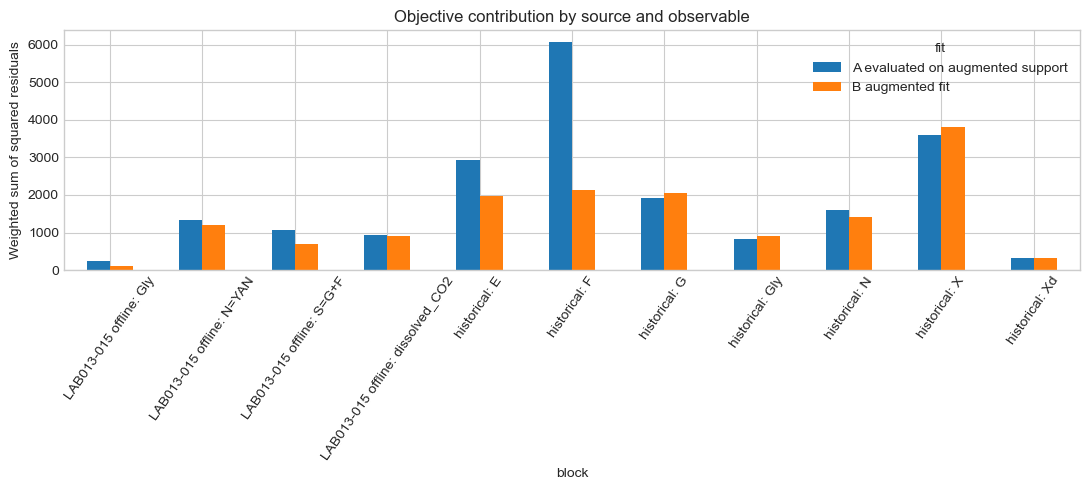

In [13]:
parameter_rows = []
for name in CORE_PARAMETERS:
    low, high = base.PARAMETER_BOUNDS[name]
    a, b = theta_A[name], theta_B[name]
    span_log = math.log(high / low)
    rel_bound_A = min(math.log(a / low), math.log(high / a)) / span_log
    rel_bound_B = min(math.log(b / low), math.log(high / b)) / span_log
    parameter_rows.append({
        "parameter": name, "A_historical": a, "B_augmented": b,
        "percent_change": 100.0 * (b / a - 1.0),
        "lower_bound": low, "upper_bound": high,
        "A_at_bound": rel_bound_A < 0.01, "B_at_bound": rel_bound_B < 0.01,
    })
parameter_comparison = pd.DataFrame(parameter_rows)
display(parameter_comparison)

contribution_B = contribution_table(theta_B, "B augmented fit", True)
all_contributions = pd.concat([
    contribution_A_historical, contribution_A_augmented_support, contribution_B
], ignore_index=True)
display(all_contributions)

hist_A = contribution_A_historical["WSSE"].sum()
hist_B = contribution_B.query("source == 'historical'")["WSSE"].sum()
aug_A = contribution_A_augmented_support["WSSE"].sum()
aug_B = contribution_B["WSSE"].sum()
objective_comparison = pd.DataFrame([
    {"comparison": "historical support", "A_WSSE": hist_A, "B_WSSE": hist_B,
     "percent_change_B_vs_A": 100 * (hist_B / hist_A - 1)},
    {"comparison": "common augmented support", "A_WSSE": aug_A, "B_WSSE": aug_B,
     "percent_change_B_vs_A": 100 * (aug_B / aug_A - 1)},
])
display(objective_comparison)

fig, ax = plt.subplots(figsize=(11, 5))
pivot = (all_contributions[all_contributions["fit"].isin(["A evaluated on augmented support", "B augmented fit"])]
         .assign(block=lambda x: x["source"] + ": " + x["observable"])
         .pivot(index="block", columns="fit", values="WSSE").fillna(0))
pivot.plot.bar(ax=ax)
ax.set_ylabel("Weighted sum of squared residuals")
ax.set_title("Objective contribution by source and observable")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout()
plt.show()

## 12. Historical fit before and after adding LAB013–LAB015 offline

,fit,state,n,RMSE
0,A historical,E,44,16.493131
1,A historical,F,91,20.430175
2,A historical,G,91,11.483547
3,A historical,Gly,91,1.104713
4,A historical,N,91,0.062389
5,A historical,X,100,0.559478
6,A historical,Xd,100,0.115533
7,B augmented,E,44,13.390495
8,B augmented,F,91,12.097989
9,B augmented,G,91,11.886710


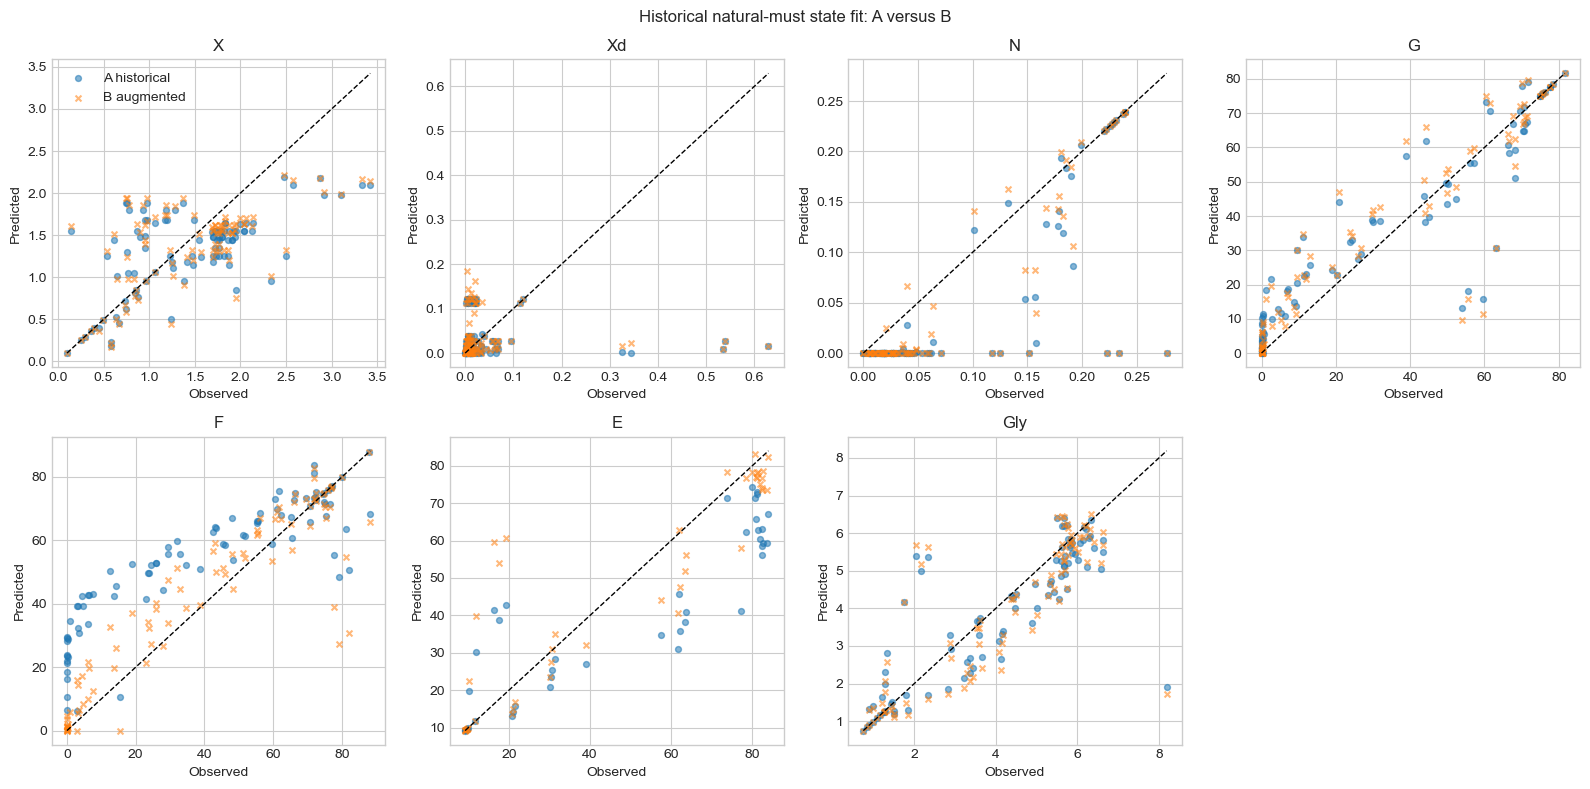

In [14]:
historical_curve_rows = []
for batch in historical_batches:
    for fit_label, theta in (("A historical", theta_A), ("B augmented", theta_B)):
        simulation = base.simulate(batch, theta, batch.time)
        for state in base.STATE_NAMES:
            obs = np.asarray(batch.observations[state], float)
            mask = np.isfinite(obs)
            pred = simulation.loc[batch.time, state].to_numpy(float)
            for time_h, observed, predicted in zip(batch.time[mask], obs[mask], pred[mask]):
                historical_curve_rows.append({"batch": batch.batch, "fit": fit_label, "state": state,
                                              "time_h": time_h, "observed": observed, "predicted": predicted})
historical_curves = pd.DataFrame(historical_curve_rows)
historical_metrics = (historical_curves.assign(sq=lambda x: (x.predicted - x.observed)**2)
                      .groupby(["fit", "state"], as_index=False)
                      .agg(n=("sq", "size"), RMSE=("sq", lambda s: float(np.sqrt(s.mean())))))
display(historical_metrics)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, state in zip(axes.ravel(), base.STATE_NAMES):
    group = historical_curves[historical_curves["state"].eq(state)]
    lim_low = min(group["observed"].min(), group["predicted"].min())
    lim_high = max(group["observed"].max(), group["predicted"].max())
    for label, marker in (("A historical", "o"), ("B augmented", "x")):
        subset = group[group["fit"].eq(label)]
        ax.scatter(subset["observed"], subset["predicted"], s=18, alpha=0.55, marker=marker, label=label)
    ax.plot([lim_low, lim_high], [lim_low, lim_high], "k--", lw=1)
    ax.set_title(state)
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
axes[1, 3].axis("off")
axes[0, 0].legend()
fig.suptitle("Historical natural-must state fit: A versus B")
fig.tight_layout()
plt.show()

## 13. LAB013–LAB015 substrate, nitrogen and glycerol

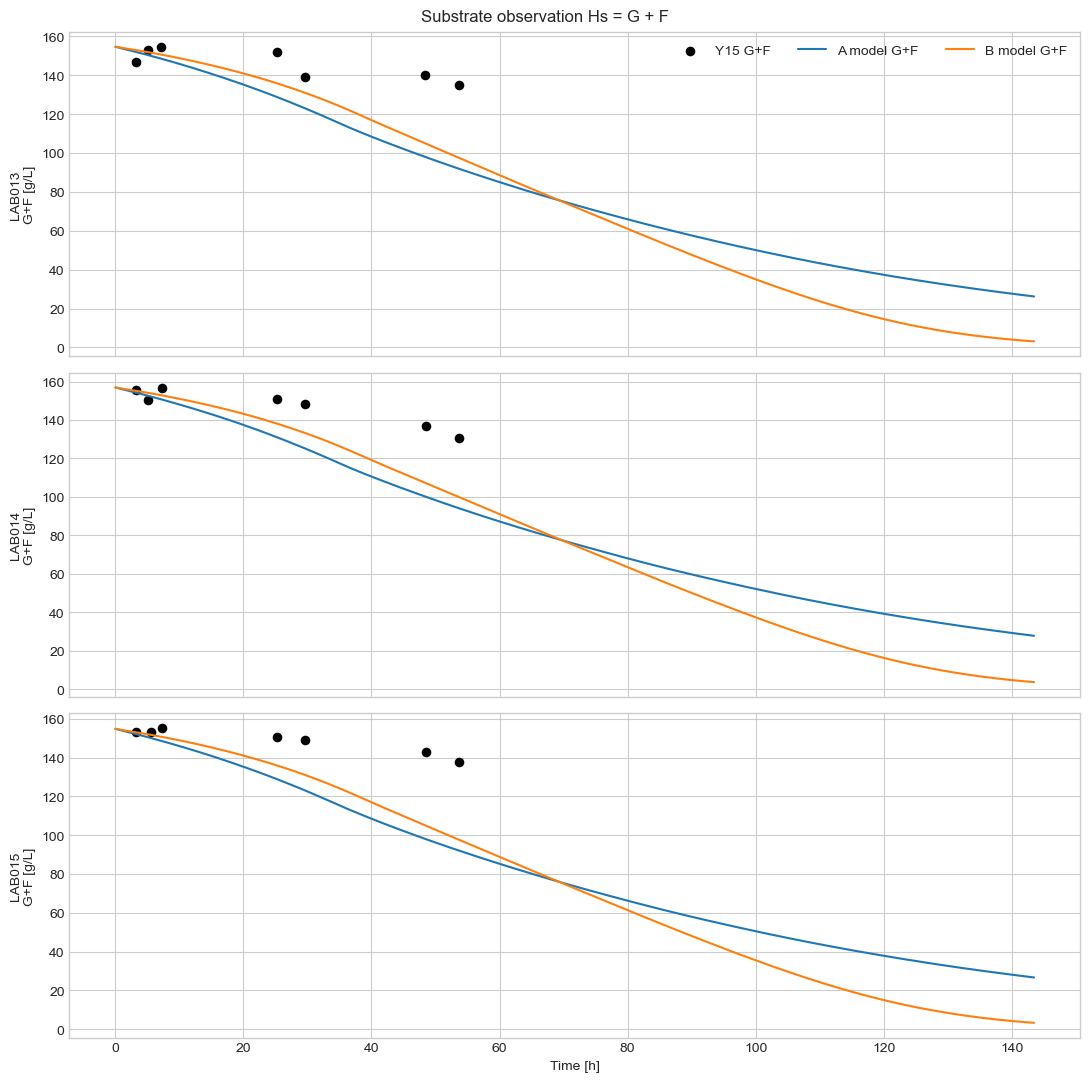

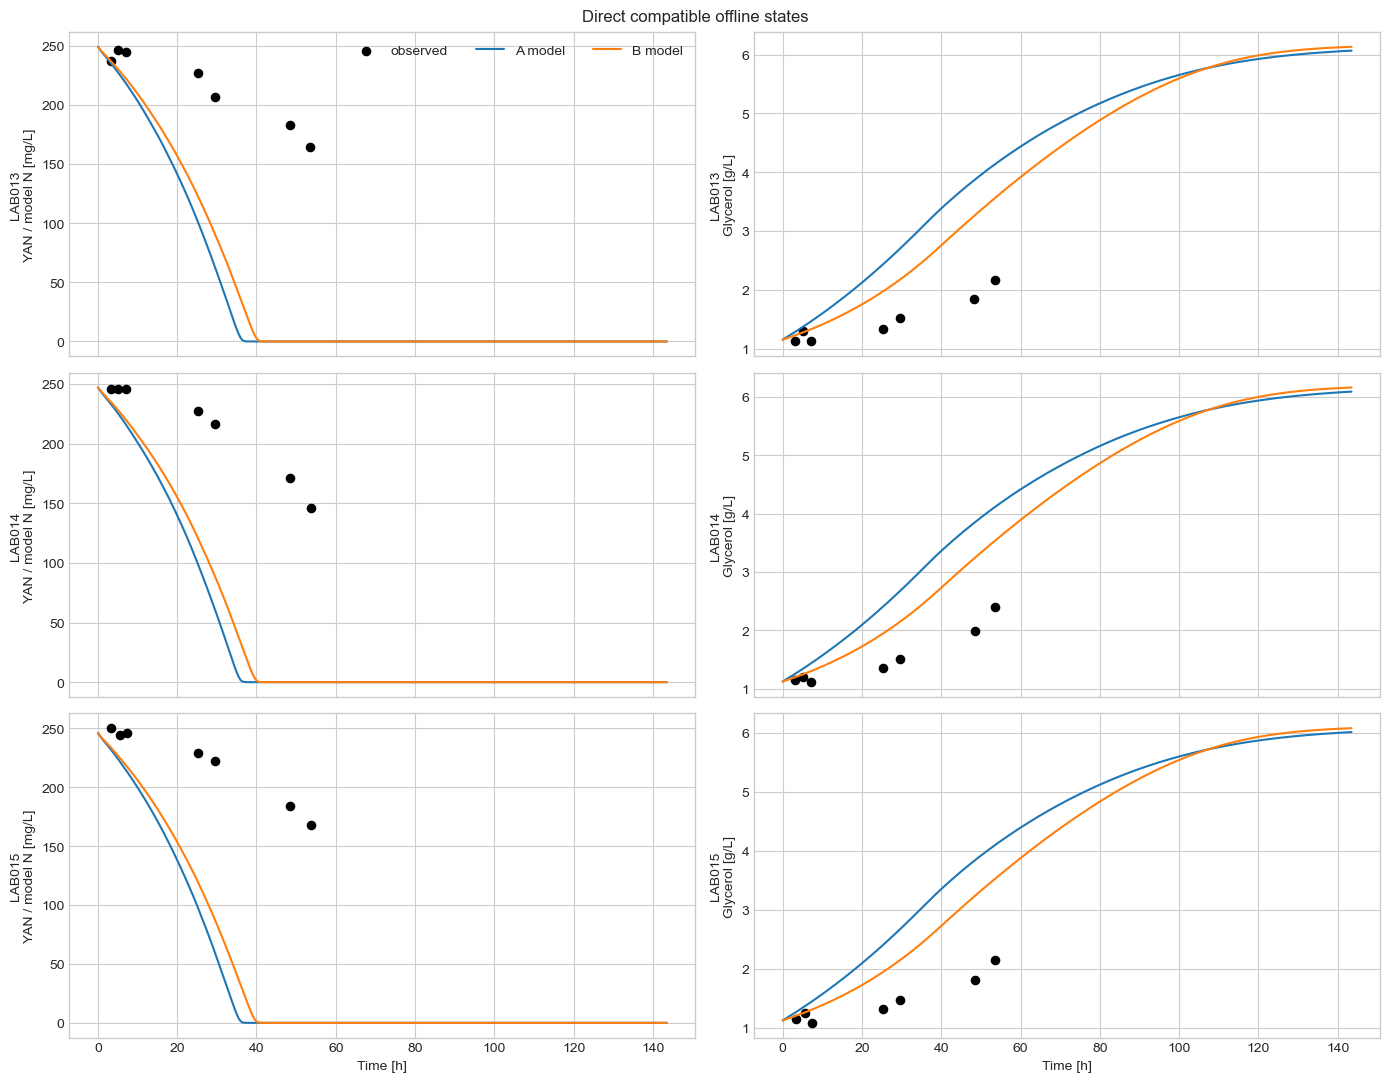

In [15]:
lab_predictions = {}
for lab, batch in lab_batches.items():
    lab_predictions[(lab, "A")] = base.simulate(batch, theta_A, batch.time)
    lab_predictions[(lab, "B")] = base.simulate(batch, theta_B, batch.time)

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
for ax, lab in zip(axes, LABS):
    obs = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    ax.scatter(obs["time_h_model"], obs["glucose_fructose_g_L"], color="black", s=35, label="Y15 G+F")
    for fit, color in (("A", "tab:blue"), ("B", "tab:orange")):
        sim = lab_predictions[(lab, fit)]
        ax.plot(sim.index, sim["G"] + sim["F"], color=color, label=f"{fit} model G+F")
    ax.set_ylabel(f"{lab}\nG+F [g/L]")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time [h]")
fig.suptitle("Substrate observation Hs = G + F")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
for row, lab in enumerate(LABS):
    obs = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    for col, (state, observed_column, factor, ylabel) in enumerate([
        ("N", "YAN_mg_L", 1000.0, "YAN / model N [mg/L]"),
        ("Gly", "glycerol_g_L", 1.0, "Glycerol [g/L]"),
    ]):
        ax = axes[row, col]
        ax.scatter(obs["time_h_model"], obs[observed_column], color="black", s=35, label="observed")
        for fit, color in (("A", "tab:blue"), ("B", "tab:orange")):
            sim = lab_predictions[(lab, fit)]
            ax.plot(sim.index, factor * sim[state], color=color, label=f"{fit} model")
        ax.set_ylabel(f"{lab}\n{ylabel}")
axes[0, 0].legend(ncol=3)
axes[-1, 0].set_xlabel("Time [h]")
axes[-1, 1].set_xlabel("Time [h]")
fig.suptitle("Direct compatible offline states")
fig.tight_layout()
plt.show()

In [16]:
lab_fit_metrics_rows = []
for lab in LABS:
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    for fit, theta in (("A", theta_A), ("B", theta_B)):
        sim = lab_predictions[(lab, fit)]
        t = dyn["time_h_model"].to_numpy(float)
        values = {
            "S=G+F": (dyn["glucose_fructose_g_L"].to_numpy(float), np.interp(t, sim.index, sim.G + sim.F), "g/L"),
            "N=YAN": (dyn["YAN_mg_L"].to_numpy(float), 1000*np.interp(t, sim.index, sim.N), "mg/L"),
            "Gly": (dyn["glycerol_g_L"].to_numpy(float), np.interp(t, sim.index, sim.Gly), "g/L"),
        }
        for observable, (observed, predicted, unit) in values.items():
            lab_fit_metrics_rows.append({"lab_id": lab, "fit": fit, "observable": observable, "unit": unit,
                                         "n": len(observed), "RMSE": float(np.sqrt(np.mean((predicted-observed)**2))),
                                         "bias_pred_minus_obs": float(np.mean(predicted-observed))})
lab_fit_metrics = pd.DataFrame(lab_fit_metrics_rows)
display(lab_fit_metrics)

,lab_id,fit,observable,unit,n,RMSE,bias_pred_minus_obs
0,LAB013,A,S=G+F,g/L,7,25.305953,-18.210889
1,LAB013,A,N=YAN,mg/L,7,118.360965,-94.893123
2,LAB013,A,Gly,g/L,7,1.237317,0.975146
3,LAB013,B,S=G+F,g/L,7,20.729505,-13.611099
4,LAB013,B,N=YAN,mg/L,7,110.518726,-86.580312
5,LAB013,B,Gly,g/L,7,0.832702,0.625065
6,LAB014,A,S=G+F,g/L,7,22.787651,-17.364026
7,LAB014,A,N=YAN,mg/L,7,114.987700,-94.884241
8,LAB014,A,Gly,g/L,7,1.137343,0.910106
9,LAB014,B,S=G+F,g/L,7,17.854614,-12.720066


## 14. Dissolved CO$_2$ and validation-only variables

Dissolved CO$_2$ after time zero enters B through the existing latent pool. Its
initial value remains validation-only. O$_2$, Brix, density, ammonia, and PAN are
shown without forcing unsupported observation equations. Missing O$_2$ values
remain NaN.

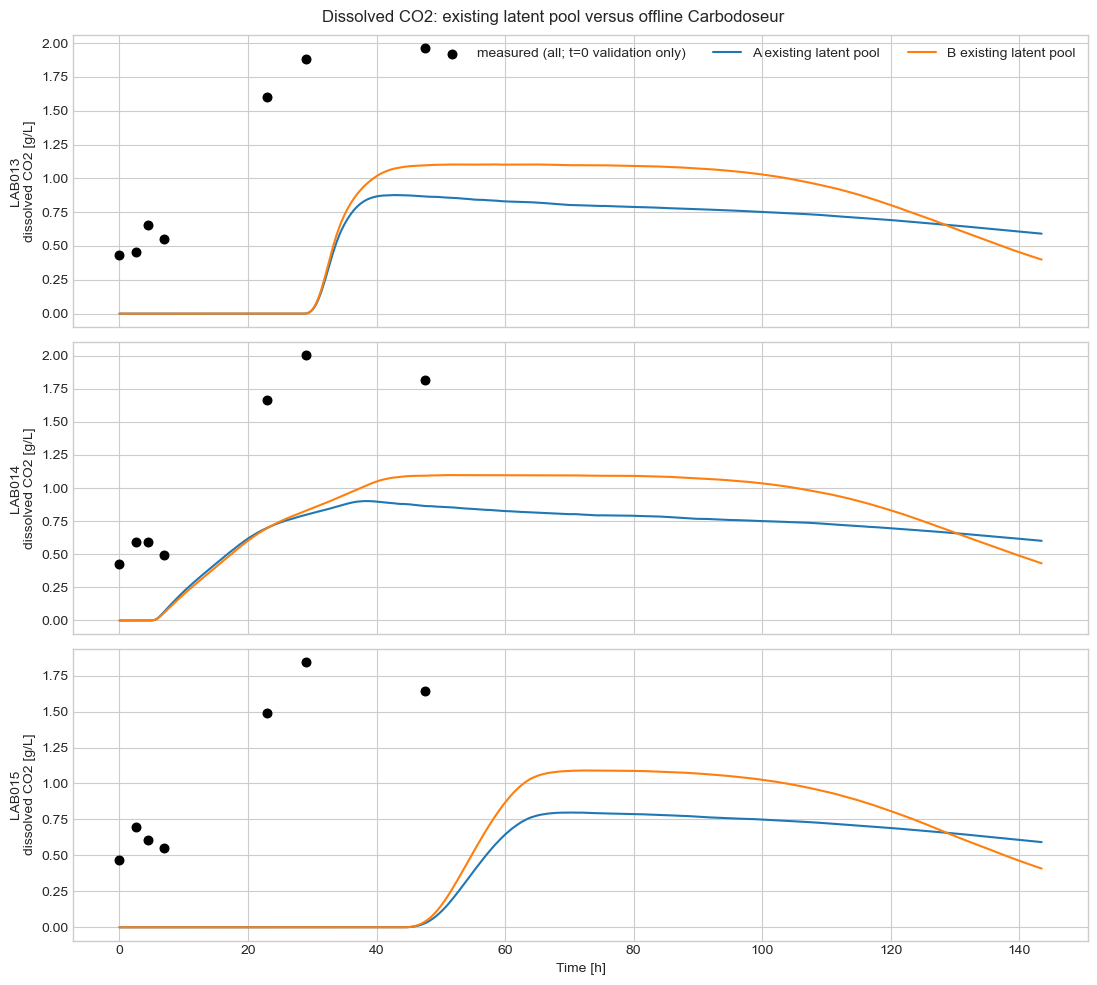

,lab_id,fit,n_fit_points,RMSE_g_L,bias_g_L
0,LAB013,A,6,1.172057,-1.039912
1,LAB013,B,6,1.139505,-1.001532
2,LAB014,A,6,0.833701,-0.788494
3,LAB014,B,6,0.787987,-0.746902
4,LAB015,A,6,1.250458,-1.133160
5,LAB015,B,6,1.248179,-1.131389


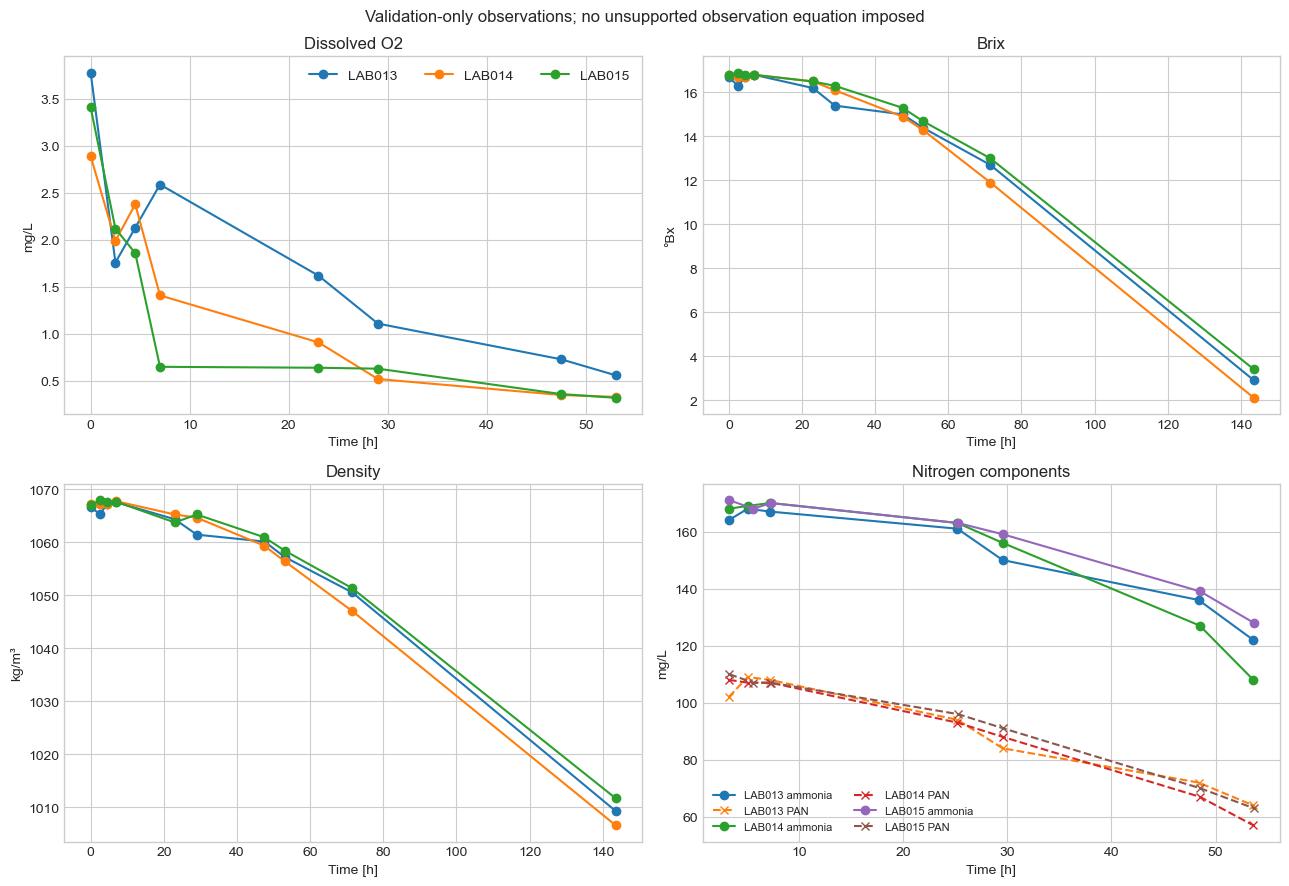

In [17]:
cache_A_lab = build_lab_driver_cache(theta_A)
cache_B_lab = build_lab_driver_cache(theta_B)
dissolved_metric_rows = []
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, lab in zip(axes, LABS):
    off = offline[offline["lab_id"].eq(lab)].sort_values("time_h_model")
    ax.scatter(off["time_h_model"], off["CO2_dissolved_actualT_mg_L"] * 1e-3,
               color="black", s=38, label="measured (all; t=0 validation only)")
    for fit, cache, color in (("A", cache_A_lab, "tab:blue"), ("B", cache_B_lab, "tab:orange")):
        dissolved, *_ = dissolved_pool_grid(cache[lab])
        ax.plot(cache[lab].time_h, dissolved, color=color, label=f"{fit} existing latent pool")
        used = off[off["CO2_dissolved_actualT_mg_L"].notna() & off["time_h_model"].gt(0)]
        pred = np.interp(used["time_h_model"], cache[lab].time_h, dissolved)
        obs = used["CO2_dissolved_actualT_mg_L"].to_numpy(float) * 1e-3
        dissolved_metric_rows.append({"lab_id": lab, "fit": fit, "n_fit_points": len(obs),
                                      "RMSE_g_L": float(np.sqrt(np.mean((pred-obs)**2))),
                                      "bias_g_L": float(np.mean(pred-obs))})
    ax.set_ylabel(f"{lab}\ndissolved CO2 [g/L]")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time [h]")
fig.suptitle("Dissolved CO2: existing latent pool versus offline Carbodoseur")
fig.tight_layout()
plt.show()
dissolved_metrics = pd.DataFrame(dissolved_metric_rows)
display(dissolved_metrics)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for lab in LABS:
    off = offline[offline["lab_id"].eq(lab)]
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)]
    axes[0, 0].plot(off["time_h_model"], off["DO_value"], marker="o", label=lab)
    axes[0, 1].plot(off["time_h_model"], off["brix_degBx"], marker="o", label=lab)
    axes[1, 0].plot(off["time_h_model"], off["rho_value"], marker="o", label=lab)
    axes[1, 1].plot(dyn["time_h_model"], dyn["ammonia_mg_L"], marker="o", label=f"{lab} ammonia")
    axes[1, 1].plot(dyn["time_h_model"], dyn["PAN_mg_L"], marker="x", ls="--", label=f"{lab} PAN")
for ax, title, ylabel in zip(axes.ravel(), ["Dissolved O2", "Brix", "Density", "Nitrogen components"],
                             ["mg/L", "°Bx", "kg/m³", "mg/L"]):
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("Time [h]")
axes[0, 0].legend(ncol=3)
axes[1, 1].legend(ncol=2, fontsize=8)
fig.suptitle("Validation-only observations; no unsupported observation equation imposed")
fig.tight_layout()
plt.show()
assert offline.groupby("lab_id")["DO_value"].apply(lambda s: s.isna().sum()).eq(2).all()

## 15. Preservation of trusted historical gas-phase CO$_2$

The existing natural-must CO$_2$ observation-layer parameters are held fixed.
Rebuilding its upstream drivers with A and B tests whether the augmented biological
fit degrades the trusted historical calibration and LAB012 holdout. These gas data
remain validation-only in this notebook.

,upstream_fit,batch,role,n,rmse_g_l_h,nrmse_peak,correlation,integral_ratio_pred_over_observed_lower_bound
0,A historical,LAB004,calibration,97,0.157291,0.194948,0.634988,0.956651
1,A historical,LAB005,calibration,119,0.075453,0.106871,0.926601,1.092687
2,A historical,LAB006,calibration,139,0.087672,0.214141,0.777247,1.360551
3,A historical,LAB007,calibration,101,0.172832,0.209016,0.848006,0.902200
4,A historical,LAB008,calibration,114,0.090616,0.133800,0.892337,1.065078
5,A historical,LAB010,calibration,84,0.052161,0.139209,0.941304,1.153160
6,A historical,LAB011,calibration,76,0.443024,0.346607,0.826919,0.465974
7,A historical,LAB012,internal_holdout,98,0.318335,0.261581,0.776992,0.668023
8,B augmented,LAB004,calibration,97,0.239435,0.296758,0.675915,1.245126
9,B augmented,LAB005,calibration,119,0.259446,0.367480,0.903556,1.391974


,upstream_fit,role,mean_RMSE_g_L_h,mean_NRMSE_peak,mean_correlation
0,A historical,calibration,0.154150,0.192085,0.835343
1,A historical,internal_holdout,0.318335,0.261581,0.776992
2,B augmented,calibration,0.246841,0.348497,0.807568
3,B augmented,internal_holdout,0.457096,0.375603,0.282654


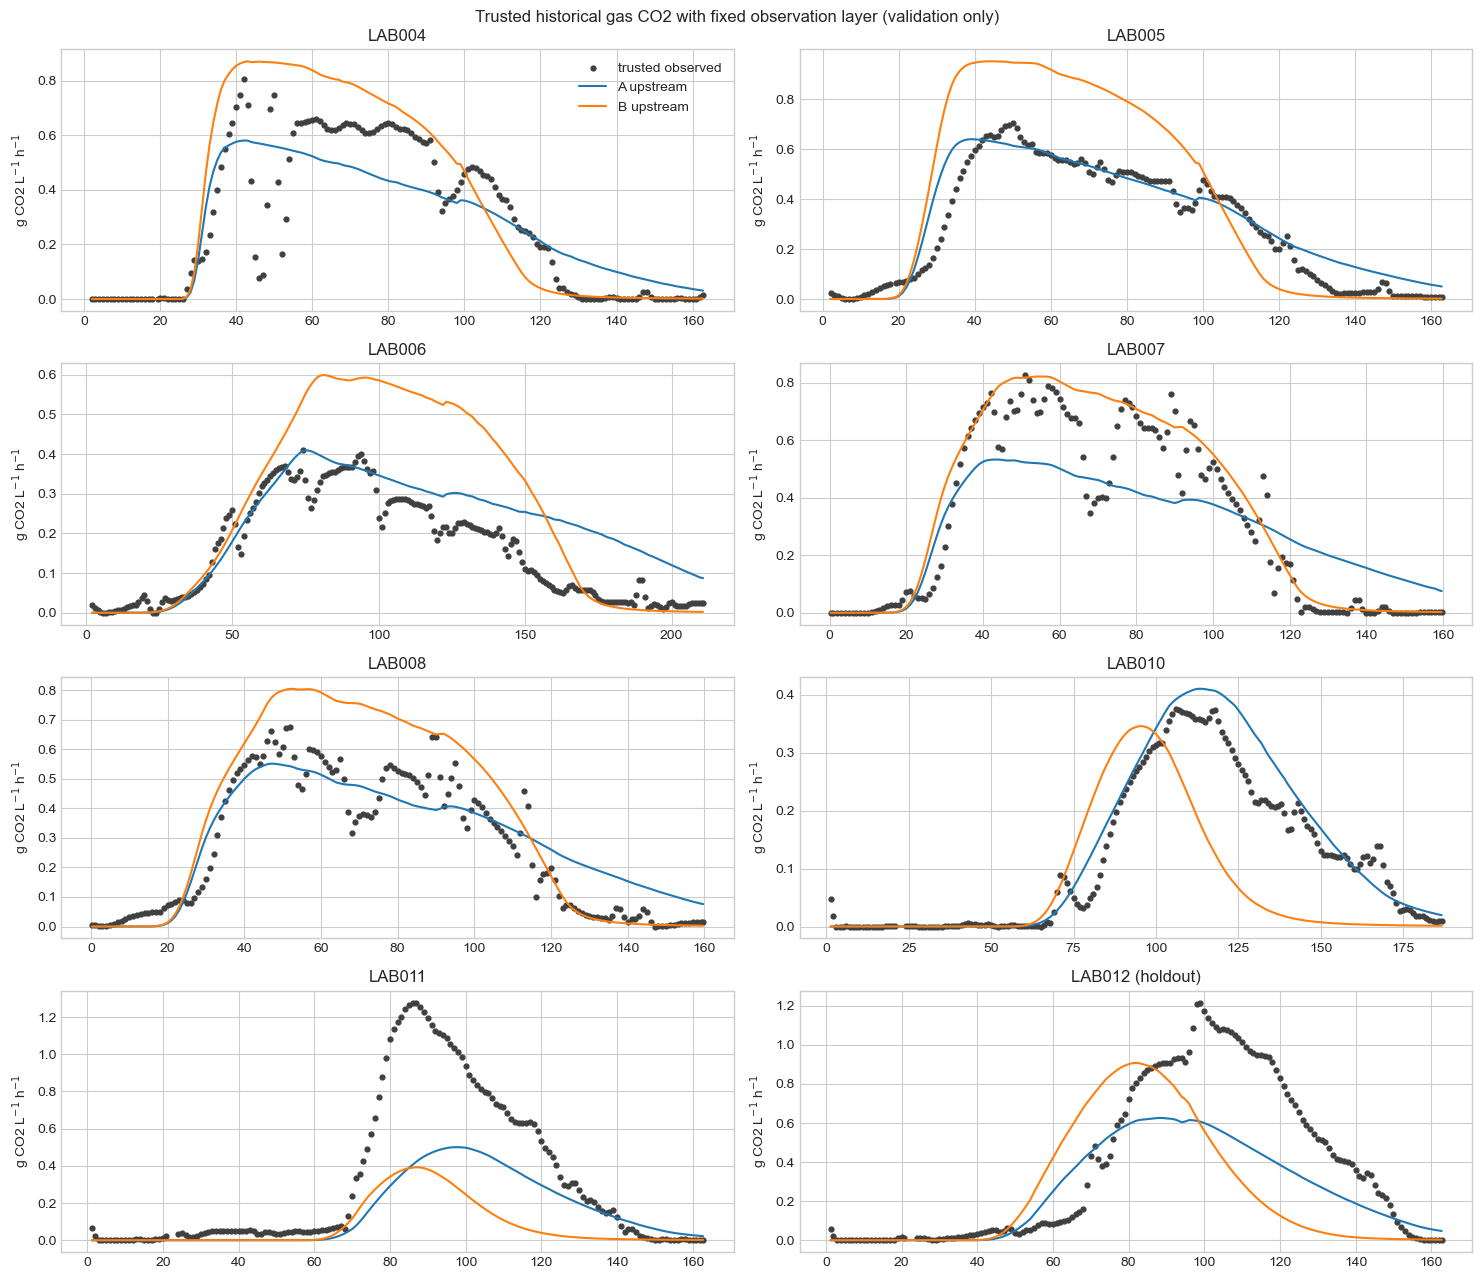

In [18]:
historical_gas_observations = pd.read_csv(requested["historical_co2"])
historical_gas_observations = historical_gas_observations[
    historical_gas_observations["matrix"].eq("natural")
].copy()
pulse_schedule = pd.read_csv(CO2_RESULTS / "effective_nutrient_pulses.csv")
pulse_schedule = pulse_schedule[pulse_schedule["matrix"].eq("natural")].rename(
    columns={"pulse_time_h": "model_pulse_time_h"}
)
historical_batches_for_gas = co2_layer.override_natural_nutrient_pulses(historical_batches, pulse_schedule)
historical_batch_map = {batch.batch: batch for batch in historical_batches_for_gas}
cache_A_hist, _ = co2_layer.build_driver_cache(
    historical_batch_map, {"natural": theta_A}, historical_gas_observations
)
cache_B_hist, _ = co2_layer.build_driver_cache(
    historical_batch_map, {"natural": theta_B}, historical_gas_observations
)
fixed_fit = {"natural": {**fixed_co2_parameters, "matrix_gain": fixed_co2_parameters["matrix_gain"]}}
pred_A_hist_gas, metrics_A_hist_gas, _ = co2_layer.predict_and_score(
    fixed_fit, historical_gas_observations, cache_A_hist
)
pred_B_hist_gas, metrics_B_hist_gas, _ = co2_layer.predict_and_score(
    fixed_fit, historical_gas_observations, cache_B_hist
)
historical_gas_metrics = pd.concat([
    metrics_A_hist_gas.assign(upstream_fit="A historical"),
    metrics_B_hist_gas.assign(upstream_fit="B augmented"),
], ignore_index=True)
display(historical_gas_metrics[["upstream_fit", "batch", "role", "n", "rmse_g_l_h",
                                "nrmse_peak", "correlation", "integral_ratio_pred_over_observed_lower_bound"]])

gas_preservation = (historical_gas_metrics.groupby(["upstream_fit", "role"], as_index=False)
                    .agg(mean_RMSE_g_L_h=("rmse_g_l_h", "mean"),
                         mean_NRMSE_peak=("nrmse_peak", "mean"),
                         mean_correlation=("correlation", "mean")))
display(gas_preservation)

joined_hist_predictions = pd.concat([
    pred_A_hist_gas.assign(upstream_fit="A"), pred_B_hist_gas.assign(upstream_fit="B")
], ignore_index=True)
batches_to_plot = sorted(joined_hist_predictions["batch"].unique())
fig, axes = plt.subplots(4, 2, figsize=(15, 13), sharex=False)
for ax, batch_name in zip(axes.ravel(), batches_to_plot):
    group = joined_hist_predictions[joined_hist_predictions["batch"].eq(batch_name)]
    observed = group[group["upstream_fit"].eq("A")]
    ax.scatter(observed["time_h"], observed["observed_g_l_h"], color="0.25", s=12, label="trusted observed")
    for fit, color in (("A", "tab:blue"), ("B", "tab:orange")):
        curve = group[group["upstream_fit"].eq(fit)]
        ax.plot(curve["time_h"], curve["predicted_g_l_h"], color=color, label=f"{fit} upstream")
    ax.set_title(batch_name + (" (holdout)" if batch_name == co2_layer.HOLDOUTS["natural"] else ""))
    ax.set_ylabel("g CO2 L$^{-1}$ h$^{-1}$")
axes[0, 0].legend()
fig.suptitle("Trusted historical gas CO2 with fixed observation layer (validation only)")
fig.tight_layout()
plt.show()

## 16. LAB013–LAB015 gas-phase CO$_2$ qualitative overlay

The same fixed observation layer is used only to show the experimental discrepancy.
No RMSE or other gas metric from LAB013–LAB015 is used to choose A or B.

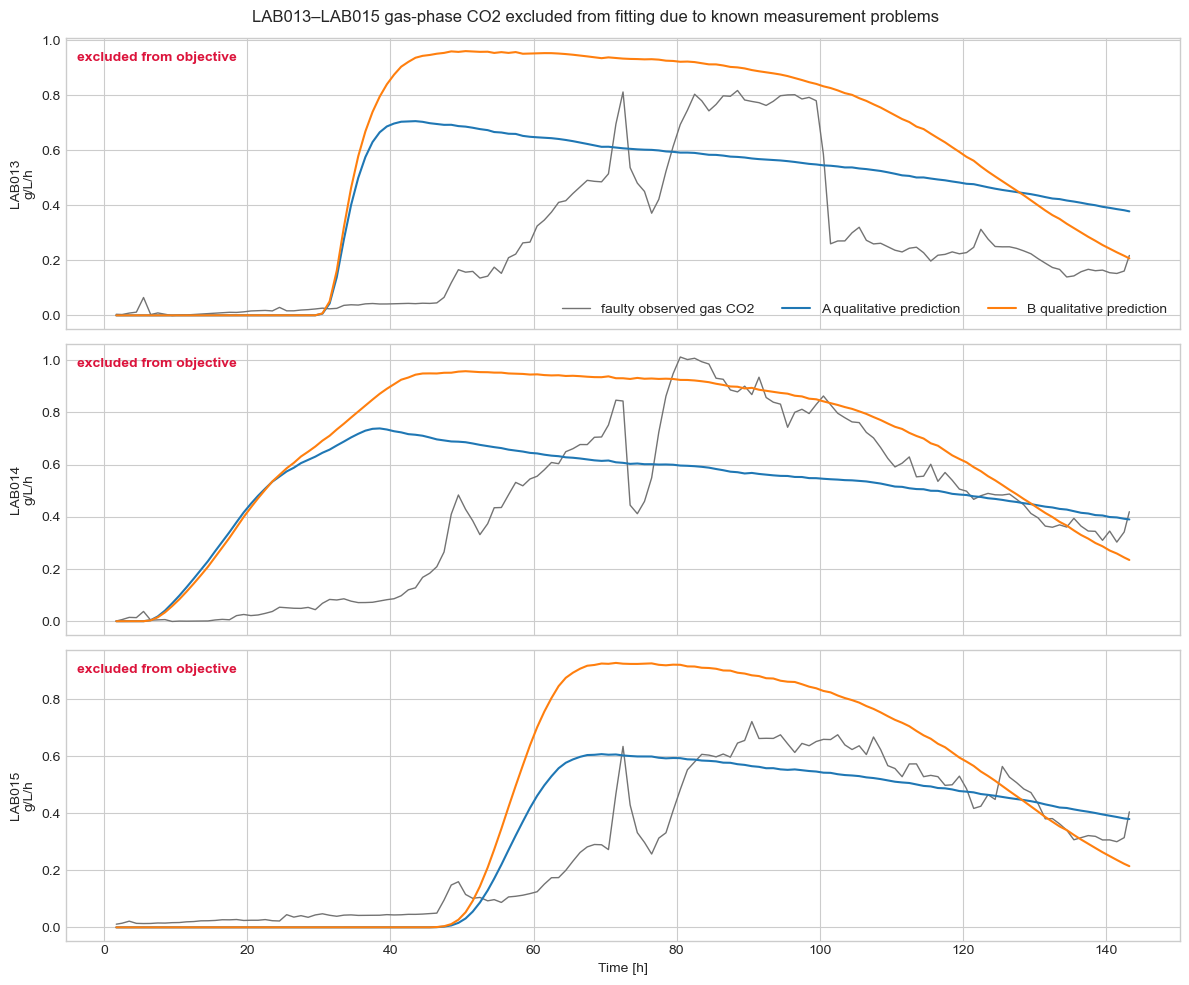

In [19]:
diagnostic_support = gas_reference.rename(columns={"lab_id": "batch", "t_h": "t_h"}).copy()
diagnostic_support["matrix"] = "natural"
diagnostic_support["calibratable"] = True  # required only for cache construction, never for fitting
diagnostic_support["chemistry_last_h"] = diagnostic_support["batch"].map(
    {lab: float(batch.time.max()) for lab, batch in lab_batches.items()}
)
diag_cache_A, _ = co2_layer.build_driver_cache(lab_batches, {"natural": theta_A}, diagnostic_support)
diag_cache_B, _ = co2_layer.build_driver_cache(lab_batches, {"natural": theta_B}, diagnostic_support)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, lab in zip(axes, LABS):
    observed = gas_reference[gas_reference["lab_id"].eq(lab)]
    ax.plot(observed["t_h"], observed["co2_rate_g_l_h"], color="0.45", lw=1, label="faulty observed gas CO2")
    for fit, cache, color in (("A", diag_cache_A, "tab:blue"), ("B", diag_cache_B, "tab:orange")):
        raw = co2_layer.raw_qgas_prediction(
            cache[lab], fixed_co2_parameters["kCO2_release_h"], fixed_co2_parameters["CO2sat_scale"],
            fixed_co2_parameters["O2_qmax_mg_gdw_h"], fixed_co2_parameters["O2_initial_scale"],
            chemistry_aligned=True, nitrogen_boost_transition=True,
            pulse_t_rise_h=fixed_co2_parameters["pulse_t_rise_h"],
            pulse_activity_gain=fixed_co2_parameters["pulse_activity_gain"], continuous_release=True,
            bounded_chemical_activation=True,
            chem_activation_start_fraction=fixed_co2_parameters["chem_activation_start_fraction"],
            chem_activation_duration_fraction=fixed_co2_parameters["chem_activation_duration_fraction"],
        )
        ax.plot(cache[lab].observation_time_h, fixed_co2_parameters["matrix_gain"] * raw,
                color=color, label=f"{fit} qualitative prediction")
    ax.text(0.01, 0.92, "excluded from objective", transform=ax.transAxes, color="crimson", weight="bold")
    ax.set_ylabel(f"{lab}\ng/L/h")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time [h]")
fig.suptitle("LAB013–LAB015 gas-phase CO2 excluded from fitting due to known measurement problems")
fig.tight_layout()
plt.show()

## 17. Practical identifiability and parameter compensation

Jacobians are with respect to log-parameters and scaled residuals. The comparison
`A historical` versus `A + LAB offline at the same theta` isolates the information
contributed by the new measurements from movement of the optimum. `B augmented`
then reports the local geometry at the new solution. Ridge-stabilized standard-error
proxies and correlations are local diagnostics, not formal confidence intervals.
The same ridge, fixed from the historical FIM scale, is used in all three cases.
A bound alone is reported as a boundary solution, not automatically as structural
non-identifiability.

,label,rank_1e-8,condition_number,smallest_singular_value,logdet_FIM_regularized,fixed_FIM_ridge,max_abs_parameter_correlation,median_log_parameter_SE_proxy
0,A historical,11,100616.576329,0.002257,46.300330,0.00008,0.997616,0.101994
1,A + LAB offline at same theta,11,99693.409304,0.002317,47.353804,0.00008,0.996483,0.096410
2,B augmented optimum,11,25538.301218,0.009597,63.532548,0.00008,0.969110,0.059976


,parameter,A_historical_SE_proxy,A_plus_LAB_same_theta_SE_proxy,B_augmented_SE_proxy,information_gain_percent_at_same_theta
0,mu0,0.012877,0.012186,0.010929,5.360838
1,qN,0.014461,0.013318,0.012483,7.904716
2,betaG0,0.099123,0.096410,0.059976,2.736915
3,betaF0,0.633060,0.515858,0.036076,18.513495
4,qEG,0.061388,0.046191,0.027432,24.755747
5,qEF,0.614673,0.501967,0.064094,18.335915
6,iG,0.271709,0.238377,0.090187,12.267488
7,iE,0.101994,0.074706,0.140813,26.754677
8,Kd0,11.915727,11.837015,0.427172,0.660571
9,gammaG0,0.063454,0.048574,0.044883,23.449489


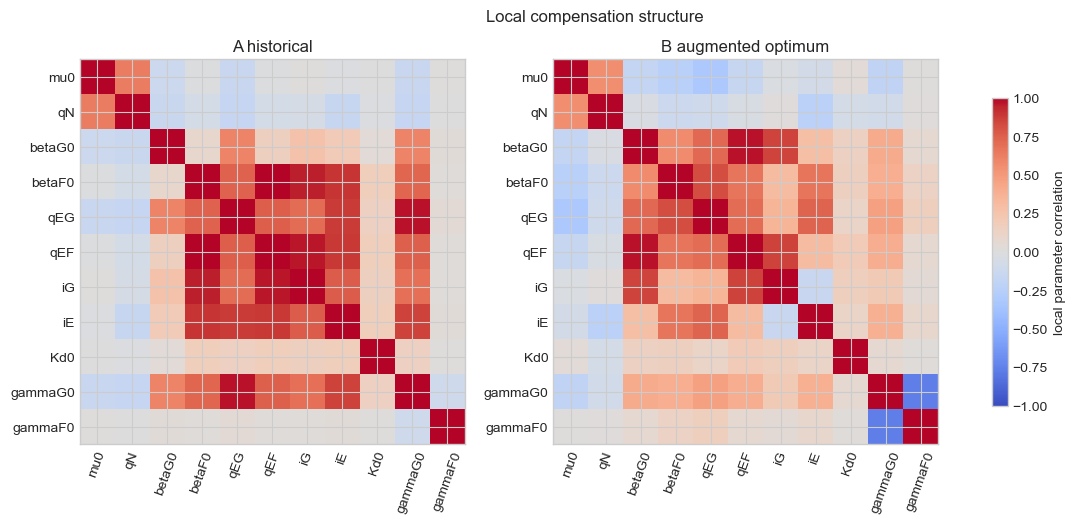

,parameter,near_best_min,near_best_max,near_best_CV
0,mu0,0.072947,0.073523,0.003674
1,qN,0.018352,0.018461,0.002782
2,betaG0,0.432459,0.559841,0.104642
3,betaF0,1.105760,1.272000,0.057579
4,qEG,0.935315,1.048674,0.048998
5,qEF,2.422611,3.140728,0.107712
6,iG,0.046391,0.062247,0.119740
7,iE,0.004044,0.005793,0.149969
8,Kd0,0.000107,0.000143,0.116247
9,gammaG0,0.063607,0.071617,0.050397


In [20]:
def finite_difference_jacobian(theta, residual_function, parameters=CORE_PARAMETERS, step=0.03):
    base_residual = residual_function(theta)
    jacobian = np.zeros((len(base_residual), len(parameters)))
    for j, name in enumerate(parameters):
        plus, minus = dict(theta), dict(theta)
        low, high = base.PARAMETER_BOUNDS[name]
        plus[name] = float(np.clip(theta[name] * math.exp(step), low, high))
        minus[name] = float(np.clip(theta[name] * math.exp(-step), low, high))
        denominator = math.log(plus[name]) - math.log(minus[name])
        jacobian[:, j] = (residual_function(plus) - residual_function(minus)) / denominator
    return jacobian

def lab_only_residual(theta):
    blocks = scaled_residual_blocks(theta, True)
    return np.concatenate([value for (source, _), value in sorted(blocks.items()) if source == "LAB013-015 offline"])

J_hist_A, _ = base.build_jacobian(theta_A, CORE_PARAMETERS, historical_batches, step=0.03)
J_lab_A = finite_difference_jacobian(theta_A, lab_only_residual)
J_aug_at_A = np.vstack([J_hist_A, J_lab_A])
J_aug_at_B = np.asarray(best_result.jac, dtype=float)

FIM_RIDGE = 1e-8 * max(float(np.trace(J_hist_A.T @ J_hist_A)) / len(CORE_PARAMETERS), 1.0)

def fim_diagnostics(label, jacobian):
    singular = np.linalg.svd(jacobian, compute_uv=False)
    fim = jacobian.T @ jacobian
    covariance_proxy = np.linalg.inv(fim + FIM_RIDGE * np.eye(len(CORE_PARAMETERS)))
    se_proxy = np.sqrt(np.maximum(np.diag(covariance_proxy), 0.0))
    denom = np.sqrt(np.outer(np.diag(covariance_proxy), np.diag(covariance_proxy)))
    corr = np.divide(covariance_proxy, denom, out=np.zeros_like(covariance_proxy), where=denom > 0)
    offdiag = np.abs(corr - np.eye(len(corr)))
    threshold = singular[0] * 1e-8 if len(singular) else np.nan
    return {
        "label": label, "jacobian": jacobian, "fim": fim, "singular": singular,
        "se_proxy": se_proxy, "corr": corr,
        "rank_1e-8": int(np.sum(singular > threshold)),
        "condition_number": float(singular[0] / singular[-1]) if singular[-1] > 0 else np.inf,
        "smallest_singular_value": float(singular[-1]),
        "logdet_FIM_regularized": float(np.linalg.slogdet(fim + np.eye(len(fim))*1e-9)[1]),
        "fixed_FIM_ridge": FIM_RIDGE,
        "max_abs_parameter_correlation": float(offdiag.max()),
        "median_log_parameter_SE_proxy": float(np.median(se_proxy)),
    }

identifiability_objects = [
    fim_diagnostics("A historical", J_hist_A),
    fim_diagnostics("A + LAB offline at same theta", J_aug_at_A),
    fim_diagnostics("B augmented optimum", J_aug_at_B),
]
identifiability_summary = pd.DataFrame([
    {key: value for key, value in obj.items() if key not in {"jacobian", "fim", "singular", "se_proxy", "corr"}}
    for obj in identifiability_objects
])
display(identifiability_summary)

se_comparison = pd.DataFrame({
    "parameter": CORE_PARAMETERS,
    "A_historical_SE_proxy": identifiability_objects[0]["se_proxy"],
    "A_plus_LAB_same_theta_SE_proxy": identifiability_objects[1]["se_proxy"],
    "B_augmented_SE_proxy": identifiability_objects[2]["se_proxy"],
})
se_comparison["information_gain_percent_at_same_theta"] = 100 * (
    1 - se_comparison["A_plus_LAB_same_theta_SE_proxy"] / se_comparison["A_historical_SE_proxy"]
)
display(se_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, obj in zip(axes, (identifiability_objects[0], identifiability_objects[2])):
    image = ax.imshow(obj["corr"], vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(CORE_PARAMETERS)), CORE_PARAMETERS, rotation=70)
    ax.set_yticks(range(len(CORE_PARAMETERS)), CORE_PARAMETERS)
    ax.set_title(obj["label"])
fig.colorbar(image, ax=axes, shrink=0.8, label="local parameter correlation")
fig.suptitle("Local compensation structure")
plt.show()

near_best = fit_starts[fit_starts["WSSE"] <= fit_starts["WSSE"].min() * 1.01]
multistart_stability = pd.DataFrame({
    "parameter": CORE_PARAMETERS,
    "near_best_min": [near_best[p].min() for p in CORE_PARAMETERS],
    "near_best_max": [near_best[p].max() for p in CORE_PARAMETERS],
    "near_best_CV": [near_best[p].std(ddof=0) / max(abs(near_best[p].mean()), 1e-12) for p in CORE_PARAMETERS],
})
display(multistart_stability)

## Information added by LAB013–LAB015 offline measurements

In [21]:
info_A = identifiability_summary[identifiability_summary["label"].eq("A historical")].iloc[0]
info_added = identifiability_summary[identifiability_summary["label"].eq("A + LAB offline at same theta")].iloc[0]
n_se_improved = int((se_comparison["information_gain_percent_at_same_theta"] > 0).sum())
median_info_gain = float(se_comparison["information_gain_percent_at_same_theta"].median())
max_parameter_change = parameter_comparison.loc[parameter_comparison["percent_change"].abs().idxmax()]
hist_change = float(objective_comparison.loc[objective_comparison["comparison"].eq("historical support"), "percent_change_B_vs_A"].iloc[0])
total_change = float(objective_comparison.loc[objective_comparison["comparison"].eq("common augmented support"), "percent_change_B_vs_A"].iloc[0])
bound_A = parameter_comparison.query("A_at_bound")["parameter"].tolist()
bound_B = parameter_comparison.query("B_at_bound")["parameter"].tolist()

display(Markdown(f"""
The augmented data add {int(contribution_A_augmented_support.query("source == 'LAB013-015 offline'")["n"].sum())}
scaled residuals: total substrate, repository-compatible YAN, glycerol, and dynamic
dissolved CO$_2$. At the same parameter point, the smallest singular value changes
from **{info_A.smallest_singular_value:.3g}** to **{info_added.smallest_singular_value:.3g}**;
{n_se_improved}/{len(CORE_PARAMETERS)} local log-parameter uncertainty proxies decrease,
with a median reduction of **{median_info_gain:.1f}%**.

After refitting, the common augmented-support objective changes by **{total_change:.1f}%**,
while the historical-only contribution changes by **{hist_change:.1f}%**. The largest
parameter movement is `{max_parameter_change.parameter}`
({max_parameter_change.percent_change:+.1f}%). Boundary solutions change from
`{bound_A}` in A to `{bound_B}` in B. These diagnostics distinguish added local
information from a claim of structural identifiability. Because A is the saved prior
estimate and B is newly optimized, objective changes combine parameter movement with
the added residual block; the same-theta Jacobian comparison is the isolated measure
of information added by LAB013–LAB015.
"""))


The augmented data add 81
scaled residuals: total substrate, repository-compatible YAN, glycerol, and dynamic
dissolved CO$_2$. At the same parameter point, the smallest singular value changes
from **0.00226** to **0.00232**;
11/11 local log-parameter uncertainty proxies decrease,
with a median reduction of **12.3%**.

After refitting, the common augmented-support objective changes by **-25.6%**,
while the historical-only contribution changes by **-27.0%**. The largest
parameter movement is `iE`
(-89.9%). Boundary solutions change from
`['gammaF0']` in A to `['gammaF0']` in B. These diagnostics distinguish added local
information from a claim of structural identifiability. Because A is the saved prior
estimate and B is newly optimized, objective changes combine parameter movement with
the added residual block; the same-theta Jacobian comparison is the isolated measure
of information added by LAB013–LAB015.


## Conclusions from LAB013–LAB015

In [22]:
substrate_summary = lab_fit_metrics.groupby(["fit", "observable"])["RMSE"].mean().unstack()
dissolved_summary = dissolved_metrics.groupby("fit")["RMSE_g_L"].mean()
gas_cal = gas_preservation[gas_preservation["role"].eq("calibration")].set_index("upstream_fit")
gas_hold = gas_preservation[gas_preservation["role"].eq("internal_holdout")].set_index("upstream_fit")
stable_starts = int(len(near_best))
b_bounds_text = ", ".join(bound_B) if bound_B else "none"
parameter_change_median = float(parameter_comparison["percent_change"].abs().median())

conclusions = f"""
1. **Measurements incorporated directly.** LAB013–LAB015 gas-phase CO₂ was not used anywhere in
   parameter estimation because of the known flowmeter/measurement failures. The
   triplicate contributes only reliable offline measurements: Y15 total substrate
   through $H_S=G+F$, YAN through the repository mapping $N=10^{{-3}}YAN$, glycerol
   through `Gly`, and dissolved CO₂ after time zero through the already implemented
   latent transfer-layer pool.

2. **Validation-only measurements.** Ammonia and PAN remain validation because the
   model has no component nitrogen states; Brix and density have no justified
   observation function in this fit; dissolved O₂ is not a biological-fit state;
   and initial dissolved CO₂ cannot be fitted because the existing layer fixes its
   initial pool to zero. Missing O₂ values remain NaN. PI rows set reactor-specific
   initial must composition and are not dynamic sample 1.

3. **Parameter movement.** The median absolute parameter change is
   **{parameter_change_median:.1f}%**; the largest is `{max_parameter_change.parameter}`
   at **{max_parameter_change.percent_change:+.1f}%**. Parameters at a numerical bound
   after augmentation: **{b_bounds_text}**. A bound is treated as a boundary warning,
   not by itself as proof of structural non-identifiability.

4. **Substrate identification.** Mean triplicate RMSE for total substrate changes from
   **{substrate_summary.loc['A', 'S=G+F']:.2f}** to
   **{substrate_summary.loc['B', 'S=G+F']:.2f} g/L**. Thus the augmented fit improves
   the representation of the observed substrate total, although a residual negative
   bias remains in every reactor.

5. **Nitrogen identification.** Mean YAN/N RMSE changes from
   **{substrate_summary.loc['A', 'N=YAN']:.2f}** to
   **{substrate_summary.loc['B', 'N=YAN']:.2f} mg/L**. This quantifies whether the
   compatible nitrogen state improves, while ammonia/PAN partitioning remains
   unidentified.

6. **Dissolved CO₂ information.** Mean dynamic RMSE changes from
   **{dissolved_summary.loc['A']:.3f}** to **{dissolved_summary.loc['B']:.3f} g/L**.
   This small improvement provides limited additional information and is conditional
   on fixed, previously calibrated transfer-layer parameters. The t=0 mismatch
   exposes the current fixed-zero initialization.

7. **Historical preservation.** The historical biological WSSE changes by
   **{hist_change:+.1f}%**. With the same fixed gas observation layer, mean trusted
   gas calibration RMSE changes from **{gas_cal.loc['A historical', 'mean_RMSE_g_L_h']:.3f}**
   to **{gas_cal.loc['B augmented', 'mean_RMSE_g_L_h']:.3f} g/L/h** and the LAB012
   holdout from **{gas_hold.loc['A historical', 'mean_RMSE_g_L_h']:.3f}** to
   **{gas_hold.loc['B augmented', 'mean_RMSE_g_L_h']:.3f} g/L/h**. The historical gas
   fit is therefore **not preserved**, so B should not replace A as the global model
   under the stated preservation criterion. These values are validation metrics,
   never fit terms.

8. **Identifiability.** At the common A parameter point, {n_se_improved} of
   {len(CORE_PARAMETERS)} local uncertainty proxies decrease and the median reduction
   is **{median_info_gain:.1f}%**. There are {stable_starts} starts within 1% of the
   best objective. Correlations, singular values, multistart spread, and bounds must
   be read together. The new data add local information but do not eliminate
   compensation or the `gammaF0` boundary solution.

9. **Structural limitations revealed.** LAB biomass and ethanol are unmeasured,
   initial biomass is a fallback, and the PI/inoculation clock is not directly
   observed. The dissolved pool has a fixed-zero initial condition, while nitrogen
   lacks ammonia/PAN component states. The conflict between improved offline states
   and degraded trusted gas predictions also shows that a fixed observation layer is
   not automatically transferable after large upstream parameter changes.

10. **Reasonable next stage.** First perform independent flowmeter validation and
    collect denser biomass, ethanol, sugar, YAN-component, and dissolved-CO₂ data.
    Then conduct a constrained joint recalibration on trusted historical gas plus
    historical and new offline observations, followed by profile likelihood or
    bootstrap analysis of only the combinations supported by the augmented Jacobian.
    Model structure should not be enlarged solely to absorb these three fermentations.
"""
display(Markdown(conclusions))


1. **Measurements incorporated directly.** LAB013–LAB015 gas-phase CO₂ was not used anywhere in
   parameter estimation because of the known flowmeter/measurement failures. The
   triplicate contributes only reliable offline measurements: Y15 total substrate
   through $H_S=G+F$, YAN through the repository mapping $N=10^{-3}YAN$, glycerol
   through `Gly`, and dissolved CO₂ after time zero through the already implemented
   latent transfer-layer pool.

2. **Validation-only measurements.** Ammonia and PAN remain validation because the
   model has no component nitrogen states; Brix and density have no justified
   observation function in this fit; dissolved O₂ is not a biological-fit state;
   and initial dissolved CO₂ cannot be fitted because the existing layer fixes its
   initial pool to zero. Missing O₂ values remain NaN. PI rows set reactor-specific
   initial must composition and are not dynamic sample 1.

3. **Parameter movement.** The median absolute parameter change is
   **17.2%**; the largest is `iE`
   at **-89.9%**. Parameters at a numerical bound
   after augmentation: **gammaF0**. A bound is treated as a boundary warning,
   not by itself as proof of structural non-identifiability.

4. **Substrate identification.** Mean triplicate RMSE for total substrate changes from
   **25.20** to
   **20.43 g/L**. Thus the augmented fit improves
   the representation of the observed substrate total, although a residual negative
   bias remains in every reactor.

5. **Nitrogen identification.** Mean YAN/N RMSE changes from
   **119.16** to
   **110.88 mg/L**. This quantifies whether the
   compatible nitrogen state improves, while ammonia/PAN partitioning remains
   unidentified.

6. **Dissolved CO₂ information.** Mean dynamic RMSE changes from
   **1.085** to **1.059 g/L**.
   This small improvement provides limited additional information and is conditional
   on fixed, previously calibrated transfer-layer parameters. The t=0 mismatch
   exposes the current fixed-zero initialization.

7. **Historical preservation.** The historical biological WSSE changes by
   **-27.0%**. With the same fixed gas observation layer, mean trusted
   gas calibration RMSE changes from **0.154**
   to **0.247 g/L/h** and the LAB012
   holdout from **0.318** to
   **0.457 g/L/h**. The historical gas
   fit is therefore **not preserved**, so B should not replace A as the global model
   under the stated preservation criterion. These values are validation metrics,
   never fit terms.

8. **Identifiability.** At the common A parameter point, 11 of
   11 local uncertainty proxies decrease and the median reduction
   is **12.3%**. There are 3 starts within 1% of the
   best objective. Correlations, singular values, multistart spread, and bounds must
   be read together. The new data add local information but do not eliminate
   compensation or the `gammaF0` boundary solution.

9. **Structural limitations revealed.** LAB biomass and ethanol are unmeasured,
   initial biomass is a fallback, and the PI/inoculation clock is not directly
   observed. The dissolved pool has a fixed-zero initial condition, while nitrogen
   lacks ammonia/PAN component states. The conflict between improved offline states
   and degraded trusted gas predictions also shows that a fixed observation layer is
   not automatically transferable after large upstream parameter changes.

10. **Reasonable next stage.** First perform independent flowmeter validation and
    collect denser biomass, ethanol, sugar, YAN-component, and dissolved-CO₂ data.
    Then conduct a constrained joint recalibration on trusted historical gas plus
    historical and new offline observations, followed by profile likelihood or
    bootstrap analysis of only the combinations supported by the augmented Jacobian.
    Model structure should not be enlarged solely to absorb these three fermentations.


## Final exclusion and reproducibility checks

This cell verifies the executable objective registry, residual provenance, source
paths, and figure production. The explicit printout is the final guard against any
accidental use of LAB013–LAB015 gas CO$_2$.

In [23]:
assert "gas_phase_CO2" not in LAB_FIT_OBSERVABLES
assert not objective_registry.query(
    "source == 'LAB013–LAB015' and observable == 'gas_phase_CO2'"
)[["used_in_A", "used_in_B"]].any(axis=None)
assert all(path.is_absolute() for path in requested.values())  # resolved internally
assert all(str(path.relative_to(ROOT)) for path in requested.values())  # provenance is repository-relative
plt.close("all")
assert len(plt.get_fignums()) == 0  # every generated figure was shown before cleanup
assert np.isfinite(objective_residual(theta_B, True)).all()

for lab in LABS:
    used = bool(gas_reference.loc[gas_reference["lab_id"].eq(lab), "used_in_fit"].any())
    assert used is False
    print(f"{lab} gas CO2 used in fit: {used}")
print("Historical gas CO2 used in biological objective A:", False)
print("Historical gas CO2 used in biological objective B:", False)
print("Notebook completed with all fit terms drawn from the declared objective registry.")

LAB013 gas CO2 used in fit: False
LAB014 gas CO2 used in fit: False
LAB015 gas CO2 used in fit: False
Historical gas CO2 used in biological objective A: False
Historical gas CO2 used in biological objective B: False
Notebook completed with all fit terms drawn from the declared objective registry.
